<a href="https://colab.research.google.com/github/jsanchezv4/seriesdetiempo/blob/serie-de-datos/Copia_de_suavizado_exponencial_margen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="text-align: center; color:rgb(0, 0, 0); font-family: Arial, sans-serif; background-color:rgb(137, 200, 129); padding: 10px; border-radius: 10px; box-shadow: 0 4px 8px rgba(0, 0, 0, 1.2); line-height: 0.1;">

### **Series de Tiempo**
#### **Universidad Central**
#### Maestría en Analítica de Datos
#### Jose Mauricio Sanchez V
##### jsanchezv4@ucentral.edu.co

</div>

<div style="text-align: center; color: #5a8d84; font-family: Arial, sans-serif; background-color:rgb(244, 228, 200); padding: 10px; border-radius: 2px; box-shadow: 0 5px 8px rgba(0, 0, 0, 0.5); line-height: 0.7;">

## **Suavizado Exponencial**
</div>


<div style=" color: #5a8d84; font-family: Arial, sans-serif; background-color:rgba(200, 224, 244, 0.11); padding: 10px; border-radius: 2px; box-shadow: 0 5px 8px rgba(0, 0, 0, 0.5); line-height: 1.2;">

## Introducción

Al trabajar con series de tiempo, a menudo enfrentamos el desafío de comprender y pronosticar patrones en datos que evolucionan con el tiempo.


- las ventas mensuales de una empresa,
-  la temperatura diaria de una ciudad
- el número de pacientes que llegan a un hospital cada semana.


El suavizamiento exponencial es una técnica poderosa y sencilla que  ayuda a lograr esa tarea. A diferencia de otros métodos, como las medias móviles, el suavizamiento exponencial da mayor peso a las observaciones más recientes, lo que permite adaptarse mejor a cambios o patrones recientes en los datos. Es como un "recuerdo selectivo" que enfatiza lo nuevo sin olvidar por completo el pasado.

## ¿Por qué es útil?

### Simplicidad y eficacia:
- No requiere suposiciones complejas ni modelos matemáticos avanzados. Es un punto de **entrada**  al mundo del pronóstico.
- Adaptabilidad a diferentes patrones:
Podemos ajustar el modelo para captar niveles, tendencias y estacionalidades, lo que lo convierte en una herramienta versátil para distintos contextos.

|

- Técnica para suavizar datos de series de tiempo utilizando una función de ventana exponencial.

- Difiere  del promedio móvil simple, con el tiempo las funciones exponenciales asignan pesos exponencialmente decrecientes.
  + Los pesos mayores se asignan a los valores u observaciones recientes, mientras que los pesos menores se asignan a los valores u observaciones más antiguos.
  
- Entre muchas funciones de ventana, en el procesamiento de señales, la función de suavizado exponencial generalmente se aplica para suavizar datos donde actúa como un filtro de paso bajo para eliminar el ruido de alta frecuencia.
  



<div style=" color: #5a8d84; font-family: Arial, sans-serif; background-color:rgba(200, 224, 244, 0.11); padding: 10px; border-radius: 2px; box-shadow: 0 5px 8px rgba(0, 0, 0, 0.5); line-height: 1.2;">

La suavización exponencial de Holt-Winters es una técnica de pronóstico para series temporales con tendencia y estacionalidad. Combina cuatro enfoques fundamentales:

![](https://miro.medium.com/v2/resize:fit:720/format:webp/1*X_Y6h0-00wDw_vV1V3CJwQ.png)

**Promedios Ponderados:**
Se calculan a partir de un conjunto de valores históricos, asignando diferentes pesos según una función específica (logarítmica, lineal, cuadrática, cúbica o exponencial). El objetivo es dar mayor relevancia a ciertos valores, generalmente los más recientes.

**Suavizado Exponencial (ES):**
Estima el próximo valor mediante un promedio ponderado de todos los datos previos, con pesos que disminuyen exponencialmente en el tiempo. Es adecuado para datos sin tendencia ni estacionalidad.

**Suavizado Exponencial de Holt:**
Extiende el método ES al incorporar una componente de tendencia, útil para series con crecimiento o decrecimiento.

**Suavizado Exponencial de Holt-Winters:**
Añade al método de Holt una componente estacional, permitiendo pronósticos en series con patrones recurrentes.



<div style=" color: #586cc4; font-family: Arial, sans-serif; background-color:rgba(200, 224, 244, 0.11); padding: 10px; border-radius: 2px; box-shadow: 0 5px 8px rgba(0, 0, 0, 0.5); line-height: 1.2;">

### **Promedios móviles (simples de orden k)**
$$F_{t+1} =\frac{Y_t + Y_{t-1} +……+ Y_{t-k+1}}{k}$$

- $Y_t$: observación en el período t
- $F_t$ : pronóstico para el período t


El método de los promedios móviles utiliza el promedio de los $k$
valores de datos más recientes en la serie de tiempo como el
pronóstico para el siguiente periodo.

El término móvil indica que, mientras se dispone de una nueva
observación para la serie de tiempo, reemplaza a la observación más
antigua de la ecuación anterior y se calcula un promedio nuevo.

Como resultado, el promedio cambiará, o se moverá, conforme surjan
nuevas observaciones.


**Ejemplo:** Promedios móviles (simples de orden 3)
$$F_{t+1} =\frac{Y_t + Y_{t-1} + Y_{t-2}}{3}$$


<div style=" color: #5a8d84; font-family: Arial, sans-serif; background-color:rgba(200, 224, 244, 0.11); padding: 10px; border-radius: 2px; box-shadow: 0 5px 8px rgba(0, 0, 0, 0.5); line-height: 1.2;">

| Semana | Valor de la serie de tiempo | Pronóstico del promedio móvil | Error de pronóstico | Error de pronóstico al cuadrado |
|--------|-----------------------------|-------------------------------|---------------------|---------------------------------|
| 1      | 17                          |                               |                     |                                 |
| 2      | 21                          |                               |                     |                                 |
| 3      | 19                          |                               |                     |                                 |
| 4      | 23                          | 19                            | 4                   | 16                              |
| 5      | 18                          | 21                            | -3                  | 9                               |
| 6      | 16                          | 20                            | -4                  | 16                              |
| 7      | 18                          | 18                            | 1                   | 1                               |
| 8      | 20                          | 18                            | 0                   | 0                               |
| 9      | 22                          | 20                            | 2                   | 4                               |
| 10     | 20                          | 20                            | 0                   | 0                               |
| 11     | 15                          | 20                            | -5                  | 25                              |
| 12     | 22                          | 19                            | 3                   | 9                               |
| **Totales** |                         |                               | **0**               | **92**                          |


### **Promedios Móviles   Ponderados**

En el método de promedios móviles, cada observación en el cálculo recibe el mismo peso.

- Una variación, conocida como promedios móviles ponderados, consiste en seleccionar diferentes pesos para cada valor de datos y luego calcular un
promedio ponderado de los k valores de datos más recientes como el pronóstico.

- En la mayoría de los casos la observación más reciente recibe el mayor peso, y el peso disminuye para los valores de datos más antiguos. Por ejemplo, para la serie de tiempo de las venta de nafta semanal el cálculo de un promedio móvil ponderado de tres
semanas, donde la observación más reciente recibe un peso del triple del peso dado a la observación más antigua y la siguiente
observación más antigua recibe un peso del doble que la observación más antigua.

- Para la semana 4 el cálculo es:

$$\frac{3}{6}\times 19+\frac{2}{6} \times 21+\frac{1}{6} \times 17=19.33$$

En general, si creemos que el pasado reciente es un mejor
pronosticador del futuro que el pasado distante, los pesos más
grandes deben darse a las observaciones más recientes.

## Suavizado exponencial simple

El método  se utiliza cuando no existe una tendencia o estacionalidad discernible en los datos de series temporales. Este método pondera los datos pasados ​​con ponderaciones exponencialmente decrecientes a medida que avanza hacia el pasado; es decir, cuanto más reciente sea el valor de los datos, mayor será su ponderación.

Esta ponderación supera en gran medida las limitaciones de los promedios móviles o los modelos de cambio porcentual. La ponderación utilizada se denomina medida alfa .

### Ecuación del Suavizamiento Exponencial Simple:

$$
F_t = \alpha Y_{t-1} + (1 - \alpha) F_{t-1}
$$

Donde:

- $F_t$ es el pronóstico para el tiempo $t$.
- $\alpha$ (alfa) es el factor de suavizamiento $(0 <  \alpha  < 1)$, que determina cuánto peso se asigna a la observación más reciente.
- $Y_{t-1} $ es el valor real observado en el periodo anterior.
- $ F_{t-1} $ es el pronóstico para el periodo anterior.


## Suavizamiento Exponencial Simple (SES)

El suavizamiento exponencial simple es un modelo apropiado para series de tiempo que no presentan tendencia ni estacionalidad sistemática. El modelo asume que la serie puede describirse mediante un componente de **nivel latente** que evoluciona dinámicamente en el tiempo.

A diferencia del promedio móvil, el suavizamiento exponencial asigna pesos exponencialmente decrecientes a las observaciones pasadas, otorgando mayor importancia a los datos más recientes.

---

### Ecuación de actualización del nivel

$$
\ell_t = \alpha Y_t + (1 - \alpha)\ell_{t-1}
$$

donde:

- $\ell_t$ es el nivel estimado en el tiempo $t$,
- $Y_t$ es la observación real en el tiempo $t$,
- $\alpha \in (0,1)$ es el parámetro de suavizamiento,
- $\ell_{t-1}$ es el nivel estimado en el periodo anterior.

---

### Pronóstico a un paso adelante

$$
\hat{Y}_{t+1} = \ell_t
$$

El pronóstico corresponde al nivel estimado más reciente.

---

### Interpretación dinámica

La ecuación puede reescribirse como:

$$
\ell_t = \ell_{t-1} + \alpha (Y_t - \ell_{t-1})
$$

Esto muestra que el nivel previo se ajusta en proporción al error observado:

$$
\varepsilon_t = Y_t - \ell_{t-1}
$$

El parámetro $\alpha$ controla la velocidad de adaptación del modelo:

- Si $\alpha$ es cercano a 1, el modelo reacciona rápidamente a cambios recientes.
- Si $\alpha$ es cercano a 0, el modelo es más inercial y suaviza fuertemente la serie.

---

### Expansión como promedio ponderado infinito

Desarrollando la ecuación recursivamente se obtiene:

$$
\ell_t = \alpha Y_t + \alpha(1-\alpha)Y_{t-1} + \alpha(1-\alpha)^2 Y_{t-2} + \dots
$$

Esto demuestra que el suavizamiento exponencial simple equivale a un promedio ponderado infinito con pesos que decrecen exponencialmente a medida que las observaciones se alejan en el tiempo.

---

### Inicialización

El modelo requiere un valor inicial para el nivel $\ell_1$. Algunas opciones comunes son:

- $\ell_1 = Y_1$,
- el promedio de las primeras observaciones,
- estimación conjunta mediante máxima verosimilitud.

La elección de la inicialización puede influir en los primeros pronósticos, aunque su efecto disminuye con el tiempo.

### Expansión recursiva del modelo

El modelo de suavizamiento exponencial simple puede expandirse recursivamente para mostrar su estructura como promedio ponderado infinito.

Supongamos una serie $Y_1, Y_2, Y_3, \dots$ y una inicialización $\ell_1 = Y_1$.

Para $t=2$:

$$
\ell_2 = \alpha Y_2 + (1-\alpha)\ell_1
$$

Para $t=3$:

$$
\ell_3 = \alpha Y_3 + (1-\alpha)\ell_2
$$

Sustituyendo $\ell_2$:

$$
\ell_3 = \alpha Y_3 + (1-\alpha)\left[\alpha Y_2 + (1-\alpha)Y_1\right]
$$

$$
\ell_3 = \alpha Y_3 + \alpha(1-\alpha)Y_2 + (1-\alpha)^2 Y_1
$$

Continuando el desarrollo recursivo, se obtiene la forma general:

$$
\ell_t = \alpha Y_t + \alpha(1-\alpha)Y_{t-1} + \alpha(1-\alpha)^2 Y_{t-2} + \dots
$$

Esto demuestra que el suavizamiento exponencial simple equivale a un promedio ponderado infinito con pesos que decrecen exponencialmente a medida que las observaciones se alejan en el tiempo.

A diferencia del promedio móvil simple, el modelo no utiliza una ventana finita de datos, sino que conserva memoria infinita del pasado, aunque con impacto decreciente.

### 📌 Lectura conceptual: suavizamiento como **modelo dinámico de estados**

En este curso NO vamos a tratar el suavizamiento como una “receta de promedios”.  
Lo vamos a ver como un **modelo estructural** para series univariadas, donde existen **componentes latentes (no observables)** que evolucionan en el tiempo.

En el caso general (familia ETS), el estado puede representarse como:

$$
x_t = (\ell_t, b_t, s_t)
$$

donde:

- **Nivel** $\ell_t$: línea base o “altura” de la serie.
- **Tendencia** $b_t$: velocidad de cambio del nivel.
- **Estacionalidad** $s_t$: patrón periódico que se repite (mensual, trimestral, etc.).

En el caso particular del **Suavizamiento Exponencial Simple (SES)**, el estado se reduce únicamente al nivel:

$$
x_t = \ell_t
$$

---

### Representación en forma de espacio de estados (intuición)

Para el **suavizamiento exponencial simple (SES)** (sin tendencia ni estacionalidad) el modelo puede escribirse como:

- **Ecuación de observación**

$$
y_t = \ell_{t-1} + \varepsilon_t
$$

donde la innovación se define como:

$$
\varepsilon_t = y_t - \ell_{t-1}
$$

- **Ecuación de estado (actualización del nivel)**

$$
\ell_t = \ell_{t-1} + \alpha\,\varepsilon_t
$$

Interpretación:

El nivel anterior se ajusta en proporción al error observado.  
El parámetro $\alpha$ controla la velocidad de adaptación del modelo.

- Si $\alpha$ es grande, el modelo reacciona rápidamente a cambios recientes.
- Si $\alpha$ es pequeño, el modelo es más estable y presenta mayor inercia.

✅ Esta perspectiva será fundamental cuando trabajemos la familia completa de modelos **ETS (Error–Trend–Seasonality)** como modelos de estado.

# Constante de Suavización $\alpha = 0.2$



| Semana $t$ | Valor de la serie de tiempo $Y_t$ | Pronóstico de suavización exponencial $F_t$ | Error de pronóstico $Y_t - F_t$ |
|-------------------|-----------------------------------------|--------------------------------------------------|----------------------------------------|
| 1                 | 17                                      | -                                               | -                                      |
| 2                 | 21                                      | 17.00                                           | 4.00                                   |
| 3                 | 19                                      | 17.80                                           | 1.20                                   |
| 4                 | 23                                      | 18.04                                           | 4.96                                   |
| 5                 | 18                                      | 19.03                                           | -1.03                                  |
| 6                 | 16                                      | 18.83                                           | -2.83                                  |
| 7                 | 20                                      | 18.26                                           | 1.74                                   |
| 8                 | 22                                      | 18.61                                           | -0.61                                  |
| 9                 | 20                                      | 18.89                                           | 3.51                                   |
| 10                | 15                                      | 19.19                                           | -4.35                                  |
| 11                | 22                                      | 19.35                                           | 0.81                                   |
| 12                | 22                                      | 18.48                                           | 3.52                                   |


$$
F_{13}=0.2 Y_{12}+0.8 F_{12}=0.2(22)+0.8(18.48)=19.18
$$

## 📘 Ejemplo Numérico: Suavizamiento Exponencial Simple (SES)  
### Constante de suavización $\alpha = 0.2$

Consideremos la siguiente serie semanal:

$$
Y_t = \{17, 21, 19, 23, 18, 16, 20, 22, 20, 15, 22, 22\}
$$

Trabajaremos el modelo en su forma estructural:

$$
\ell_t = \alpha Y_t + (1-\alpha)\ell_{t-1}
$$

donde:

- $\ell_t$ es el **nivel estimado** en el periodo $t$,
- $Y_t$ es el valor observado en el periodo $t$,
- $\alpha$ es la constante de suavización, con $0 < \alpha < 1$.

El pronóstico a un paso adelante se obtiene como:

$$
\hat{Y}_{t+1} = \ell_t
$$

---

### 🔹 Inicialización

Para iniciar el procedimiento, tomamos como valor inicial:

$$
\ell_1 = Y_1 = 17
$$

Este será nuestro primer nivel estimado.

---

### 🔹 Cálculo paso a paso

Para el periodo 2:

$$
\ell_2 = 0.2(21) + 0.8(17)
$$

$$
\ell_2 = 4.2 + 13.6 = 17.8
$$

Para el periodo 3:

$$
\ell_3 = 0.2(19) + 0.8(17.8)
$$

$$
\ell_3 = 3.8 + 14.24 = 18.04
$$

Para el periodo 4:

$$
\ell_4 = 0.2(23) + 0.8(18.04)
$$

$$
\ell_4 = 4.6 + 14.432 = 19.03
$$

El proceso continúa de manera recursiva para los periodos siguientes.

---

### 📊 Tabla de resultados

| Semana $t$ | Valor real $Y_t$ | Nivel estimado $\ell_t$ | Error $Y_t - \ell_{t-1}$ |
|------------|------------------|--------------------------|---------------------------|
| 1 | 17 | 17.00 | – |
| 2 | 21 | 17.80 | 4.00 |
| 3 | 19 | 18.04 | 1.20 |
| 4 | 23 | 19.03 | 4.96 |
| 5 | 18 | 18.83 | -1.03 |
| 6 | 16 | 18.26 | -2.83 |
| 7 | 20 | 18.61 | 1.74 |
| 8 | 22 | 19.29 | 3.39 |
| 9 | 20 | 19.43 | 0.71 |
| 10 | 15 | 18.54 | -4.43 |
| 11 | 22 | 19.23 | 3.46 |
| 12 | 22 | 19.78 | 2.77 |

*(Valores redondeados a dos decimales)*

---

### 🔹 Pronóstico para el periodo 13

El pronóstico a un paso adelante es:

$$
\hat{Y}_{13} = \ell_{12}
$$

$$
\hat{Y}_{13} = 19.78
$$

---

### 🎯 Interpretación

- El modelo no sigue exactamente cada oscilación de la serie.
- Ajusta progresivamente el nivel en proporción al error observado.
- Con $\alpha = 0.2$, el modelo es relativamente inercial.
- $\ell_t$ representa la mejor estimación del **nivel subyacente** de la serie en el periodo $t$.

### ¿Qué valor de $\alpha$?

- Si la variabilidad aleatoria de la serie de tiempo es considerable, es
preferible un valor pequeño para la constante de suavización. La razón
de esta elección es que, dado que gran parte del error de pronóstico se
debe a la variabilidad aleatoria, no queremos reaccionar de forma
exagerada y ajustar los pronósticos demasiado rápido.
- Para una serie de tiempo con relativamente poca variabilidad, los valores más grandes
de la constante de suavización tienen la ventaja de ajustar rápidamente
los pronósticos cuando ocurren errores de pronóstico y por ende
permiten que el pronóstico reaccione más rápido a las condiciones
cambiantes.

- Elegimos el valor de que minimiza el error de pronostico.

## Suavizado exponencial doble

Se utiliza muestran una tendencia pero no estacionalidad es el método de suavizado exponencial doble. El suavizado exponencial doble aplica el suavizado exponencial simple dos veces, una a los datos originales y luego a los datos resultantes del suavizado exponencial simple.

## 📘 Suavizamiento Exponencial Doble (Método de Holt)

El método de Holt extiende el suavizamiento exponencial simple para series que presentan tendencia.

El modelo introduce dos componentes dinámicos:

- $\ell_t$ : nivel estimado en el tiempo $t$.
- $b_t$ : tendencia estimada en el tiempo $t$.

---

### 1️⃣ Ecuación del nivel

$$
\ell_t = \alpha Y_t + (1 - \alpha)(\ell_{t-1} + b_{t-1})
$$

donde:

- $\alpha$ es el parámetro de suavizamiento del nivel,
- $Y_t$ es el valor observado,
- $\ell_{t-1} + b_{t-1}$ representa la proyección del nivel anterior.

---

### 2️⃣ Ecuación de la tendencia

$$
b_t = \beta(\ell_t - \ell_{t-1}) + (1 - \beta)b_{t-1}
$$

donde:

- $\beta$ es el parámetro de suavizamiento de la tendencia,
- $(\ell_t - \ell_{t-1})$ es el cambio observado en el nivel.

---

### 3️⃣ Ecuación de pronóstico

$$
\hat{Y}_{t+m} = \ell_t + m b_t
$$

donde:

- $\hat{Y}_{t+m}$ es el pronóstico a $m$ pasos adelante,
- $\ell_t$ es el nivel estimado actual,
- $b_t$ es la tendencia estimada actual,
- $m$ es el horizonte de pronóstico.

---

### 🎯 Interpretación

- El nivel captura la posición actual de la serie.
- La tendencia captura la velocidad de crecimiento o decrecimiento.
- El pronóstico extrapola linealmente el nivel según la tendencia estimada.

## 📘 Suavizamiento Exponencial Triple (Holt-Winters)

El método de Holt-Winters extiende el modelo de Holt incorporando un tercer componente dinámico: la estacionalidad.

El modelo permite capturar simultáneamente:

- $\ell_t$ : nivel estimado
- $b_t$ : tendencia estimada
- $s_t$ : componente estacional

Existen dos variantes del modelo:

- Versión **aditiva** (cuando la estacionalidad es aproximadamente constante).
- Versión **multiplicativa** (cuando la estacionalidad crece proporcionalmente al nivel).

Sea $L$ la longitud del ciclo estacional (por ejemplo, $L=12$ para datos mensuales).

---

### 1️⃣ Ecuación del nivel

**Versión aditiva**

$$
\ell_t = \alpha (Y_t - s_{t-L}) + (1-\alpha)(\ell_{t-1} + b_{t-1})
$$

**Versión multiplicativa**

$$
\ell_t = \alpha \left(\frac{Y_t}{s_{t-L}}\right) + (1-\alpha)(\ell_{t-1} + b_{t-1})
$$

---

### 2️⃣ Ecuación de la tendencia

$$
b_t = \beta(\ell_t - \ell_{t-1}) + (1-\beta)b_{t-1}
$$

---

### 3️⃣ Ecuación de la estacionalidad

**Versión aditiva**

$$
s_t = \gamma (Y_t - \ell_t) + (1-\gamma)s_{t-L}
$$

**Versión multiplicativa**

$$
s_t = \gamma \left(\frac{Y_t}{\ell_t}\right) + (1-\gamma)s_{t-L}
$$

---

### 4️⃣ Ecuación de pronóstico

Para $m$ periodos hacia el futuro:

**Versión aditiva**

$$
\hat{Y}_{t+m} = \ell_t + m b_t + s_{t+m-L}
$$

**Versión multiplicativa**

$$
\hat{Y}_{t+m} = (\ell_t + m b_t)\, s_{t+m-L}
$$

---

### 🎯 Interpretación

- El nivel captura la posición actual de la serie.
- La tendencia captura la velocidad de crecimiento o decrecimiento.
- La estacionalidad captura patrones periódicos.
- El modelo combina los tres componentes para generar pronósticos coherentes con la estructura observada en los datos.

In [ ]:
airline.index=date_range

Ajuste de los datos con suavizado exponencial de Holt-Winters
Ahora ajustaremos estos datos al suavizado exponencial simple, doble y triple respectivamente, y veremos cómo funciona.

Antes de comenzar con los modelos, primero definiremos el coeficiente de peso Alfa y el Período de Tiempo. También configuramos la frecuencia DateTime a un nivel mensual.

# Suavizamiento Exponencial doble (Holt)

### Suavizamiento exponencial Triple

## 🔷 ETS: familia de modelos estructurales (Error – Trend – Seasonality)

En la práctica, SES / Holt / Holt‑Winters son **casos particulares** dentro de una familia más general: **ETS**.

### Componentes ETS
- **E (Error):** Aditivo (A) o Multiplicativo (M)  
- **T (Trend):** Ninguna (N), Aditiva (A), o Aditiva amortiguada (Ad)  
- **S (Seasonality):** Ninguna (N), Aditiva (A) o Multiplicativa (M)

Ejemplos útiles:
- **SES** ≈ ETS(A, N, N)
- **Holt (tendencia)** ≈ ETS(A, A, N)
- **Holt‑Winters aditivo** ≈ ETS(A, A, A)
- **Holt‑Winters multiplicativo** ≈ ETS(M, A, M) (si la variabilidad crece con el nivel)

### ¿Aditivo o multiplicativo?
Una regla práctica (que luego validamos con métricas y residuos):
- Si la amplitud de las oscilaciones estacionales es **más o menos constante**, usar **estacionalidad aditiva**.
- Si la amplitud crece cuando la serie crece (efecto “proporcional”), usar **estacionalidad multiplicativa**.

### Tendencia amortiguada (damped)
Para pronósticos a horizontes largos, Holt con tendencia aditiva puede **extrapolar demasiado**.  
La tendencia amortiguada introduce un factor \(\phi\in(0,1)\) que reduce gradualmente el efecto de la tendencia en el futuro.

> En series reales (demanda, producción, matrículas), la tendencia “no suele crecer linealmente para siempre”, por eso ETS con tendencia amortiguada suele ser más realista.

In [ ]:
airline.shape

(144, 7)

## ✅ Diagnóstico y validación

Un buen pronóstico no es solo “que la curva se vea bonita”. Debemos verificar:

1. **Residuos centrados en cero** (sin sesgo sistemático).  
2. **No autocorrelación fuerte** en residuos (el modelo capturó la estructura).  
3. **Varianza razonable** y ausencia de patrones obvios.  
4. **Validación temporal**: separación train/test (o rolling origin) y métricas.

A continuación incluimos funciones mínimas para diagnóstico con:
- gráfico de residuos  
- ACF de residuos  
- prueba Ljung–Box (si está disponible)

### 1. MAE (Mean Absolute Error)
$$
MAE = \frac{1}{n} \sum_{t=1}^{n} |Y_t - \hat{Y}_t|
$$
Donde:
-  $Y_t$ es el valor real en el tiempo $ t $.
-  $\hat{Y}_t$ es el valor pronosticado en el tiempo $t$.
- $n$ es el número total de observaciones.

### 2. MSE (Mean Squared Error)
$$
MSE = \frac{1}{n} \sum_{t=1}^{n} (Y_t - \hat{Y}_t)^2
$$
Donde:
- $Y_t$ es el valor real en el tiempo $t$.
- $\hat{Y}_t$ es el valor pronosticado en el tiempo $t$.
- $n$ es el número total de observaciones.

### 3. RMSE (Root Mean Squared Error)
$$
RMSE = \sqrt{\frac{1}{n} \sum_{t=1}^{n} (Y_t - \hat{Y}_t)^2}
$$
Donde:
- $Y_t$ es el valor real en el tiempo $t$.
- $\hat{Y}_t$ es el valor pronosticado en el tiempo $t$.
- $n$ es el número total de observaciones.

### 4. MAPE (Mean Absolute Percentage Error)
$$
MAPE = \frac{100}{n} \sum_{t=1}^{n} \left| \frac{Y_t - \hat{Y}_t}{Y_t} \right|
$$
Donde:
- $Y_t$ es el valor real en el tiempo \( t \).
-  $\hat{Y}_t$ es el valor pronosticado en el tiempo $t$.
- $n$ es el número total de observaciones.


#### **Producción de café Miles de sacos de 60 Kg de café verde equivalente**

In [9]:
import pandas as pd
margen=pd.read_excel("https://raw.githubusercontent.com/jsanchezv4/seriesdetiempo/serie-de-datos/MARGEN%20FINANCIERO.xlsx")

# Map Spanish month abbreviations to numbers
spanish_month_map = {
    'Ene': '01', 'Feb': '02', 'Mar': '03', 'Abr': '04', 'May': '05', 'Jun': '06',
    'Jul': '07', 'Ago': '08', 'Sep': '09', 'Oct': '10', 'Nov': '11', 'Dic': '12'
}
margen['MES_NUM'] = margen['MES'].map(spanish_month_map)

# Create 'Fecha' from 'AÑO' and numeric 'MES', then convert to datetime
margen['Fecha'] = pd.to_datetime(margen['AÑO'].astype(str) + '-' + margen['MES_NUM'].astype(str), format='%Y-%m')
margen = margen.set_index('Fecha') # Set 'Fecha' as the index
margen

,AÑO,MES,INGRESOS FINANCIEROS,GASTOS FINANCIEROS,MARGEN FINANCIERO,TASA BANREP,MES_NUM
Fecha,,,,,,,
2005-01-01,2005,Ene,32790.077909,14093.620264,18696.457645,0.0650,01
2005-02-01,2005,Feb,32128.519993,13900.049438,18228.470556,0.0650,02
2005-03-01,2005,Mar,37128.281537,14386.374722,22741.906816,0.0650,03
2005-04-01,2005,Abr,36248.373382,14315.991990,21932.381392,0.0650,04
2005-05-01,2005,May,35987.711776,14489.772601,21497.939175,0.0650,05
...,...,...,...,...,...,...,...
2025-08-01,2025,Ago,178549.122286,95393.180770,83155.941516,0.0925,08
2025-09-01,2025,Sep,179403.454952,96400.383470,83003.071482,0.0925,09
2025-10-01,2025,Oct,180527.382704,98698.126669,81829.256035,0.0925,10


In [10]:
margen

,AÑO,MES,INGRESOS FINANCIEROS,GASTOS FINANCIEROS,MARGEN FINANCIERO,TASA BANREP,MES_NUM
Fecha,,,,,,,
2005-01-01,2005,Ene,32790.077909,14093.620264,18696.457645,0.0650,01
2005-02-01,2005,Feb,32128.519993,13900.049438,18228.470556,0.0650,02
2005-03-01,2005,Mar,37128.281537,14386.374722,22741.906816,0.0650,03
2005-04-01,2005,Abr,36248.373382,14315.991990,21932.381392,0.0650,04
2005-05-01,2005,May,35987.711776,14489.772601,21497.939175,0.0650,05
...,...,...,...,...,...,...,...
2025-08-01,2025,Ago,178549.122286,95393.180770,83155.941516,0.0925,08
2025-09-01,2025,Sep,179403.454952,96400.383470,83003.071482,0.0925,09
2025-10-01,2025,Oct,180527.382704,98698.126669,81829.256035,0.0925,10


In [12]:
# Instalar hvplot si no está instalado
!pip install hvplot

import hvplot.pandas

margen["MARGEN FINANCIERO"].hvplot(title="Margen Financiero", xlabel="Fecha", ylabel="Millones de pesos", width=800, height=400, line_width=2,
                           color="red", grid=True, legend=True, fontsize=12, fontscale=1.2, alpha=0.8)

:Curve   [Fecha]   (MARGEN FINANCIERO)

/tmp/ipykernel_9214/1011998135.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  margen_filled = margen["MARGEN FINANCIERO"].fillna(method='ffill').fillna(method='bfill')


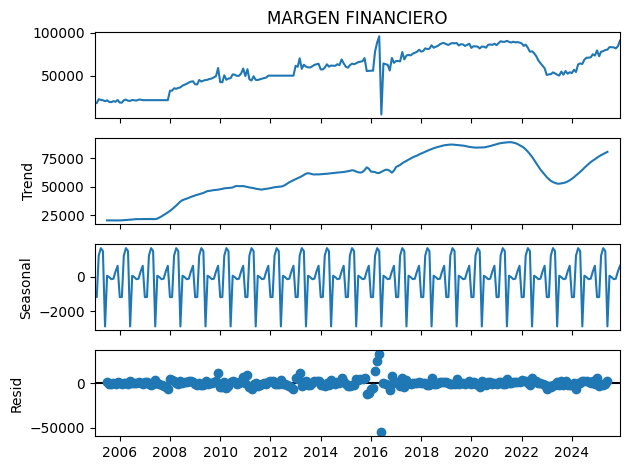

In [17]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Fill any missing values in the 'MARGEN FINANCIERO' series
margen_filled = margen["MARGEN FINANCIERO"].fillna(method='ffill').fillna(method='bfill')

# Descomposición de la serie de tiempo margen
decompose_result_margen = seasonal_decompose(margen_filled, model="additive", period=12)

# Graficar los resultados de la descomposición
decompose_result_margen.plot()
plt.show()

Contenido de 'margen' antes del ajuste de los modelos:


,AÑO,MES,INGRESOS FINANCIEROS,GASTOS FINANCIEROS,MARGEN FINANCIERO,TASA BANREP,MES_NUM,HWES3_ADD
Fecha,,,,,,,,
2005-01-01,2005,Ene,32790.077909,14093.620264,18696.457645,0.065,01,18401.439505
2005-02-01,2005,Feb,32128.519993,13900.049438,18228.470556,0.065,02,18048.292456
2005-03-01,2005,Mar,37128.281537,14386.374722,22741.906816,0.065,03,21649.715629
2005-04-01,2005,Abr,36248.373382,14315.991990,21932.381392,0.065,04,20843.488355
2005-05-01,2005,May,35987.711776,14489.772601,21497.939175,0.065,05,20385.859762


,AÑO,MES,INGRESOS FINANCIEROS,GASTOS FINANCIEROS,MARGEN FINANCIERO,TASA BANREP,MES_NUM,HWES3_ADD
Fecha,,,,,,,,
2025-08-01,2025,Ago,178549.122286,95393.180770,83155.941516,0.0925,08,NaN
2025-09-01,2025,Sep,179403.454952,96400.383470,83003.071482,0.0925,09,NaN
2025-10-01,2025,Oct,180527.382704,98698.126669,81829.256035,0.0925,10,NaN
2025-11-01,2025,Nov,182156.296644,97830.733132,84325.563512,0.0925,11,NaN
2025-12-01,2025,Dic,190722.423981,99910.595615,90811.828366,0.0925,12,NaN


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


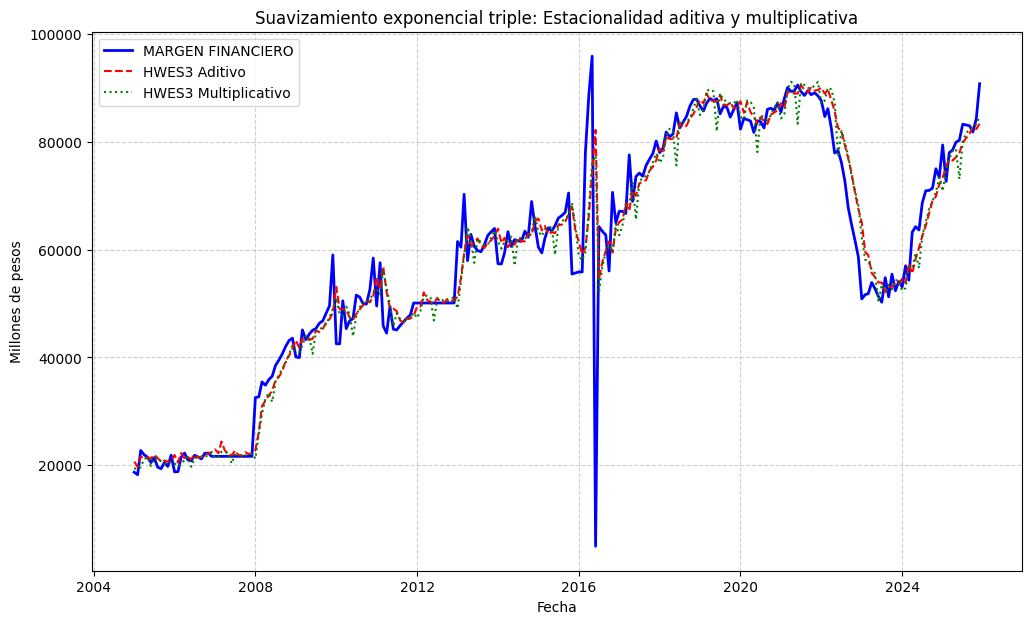

In [19]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import matplotlib.pyplot as plt

# --- Diagnóstico: Mostrar el contenido actual de 'margen' ---
print("Contenido de 'margen' antes del ajuste de los modelos:")
display(margen.head())
display(margen.tail())
# --------------------------------------------------------

# Use the 'margen_filled' series, which already handles NaNs from the previous cell.
# Create a copy to avoid modifying the original 'margen_filled' directly if a shift is applied.
series_to_model = margen_filled.copy()

# Check for non-positive values in series_to_model for the multiplicative model
min_val_series_to_model = series_to_model.min()
epsilon_shift = 0.0 # Initialize epsilon_shift

if min_val_series_to_model <= 0:
    print(f"Warning: The series contains non-positive values (min={min_val_series_to_model}).")
    print("Multiplicative Exponential Smoothing requires strictly positive data.")
    # Add a small constant to make all values strictly positive.
    # If min_val_series_to_model is negative, shift by its absolute value + a small epsilon (e.g., 0.1)
    # If min_val_series_to_model is 0, shift by a small epsilon (e.g., 0.1)
    epsilon_shift = abs(min_val_series_to_model) + 0.1
    series_for_mul_model = series_to_model + epsilon_shift
    print(f"Adding a constant of {epsilon_shift:.2f} to the series for the multiplicative model.")
else:
    series_for_mul_model = series_to_model

#Triple HWES
# Additive model can handle non-positive values (zeros or negatives)
margen["HWES3_ADD"] = ExponentialSmoothing(series_to_model, trend="add", seasonal="add", seasonal_periods=12).fit().fittedvalues

# Multiplicative model requires strictly positive values, so use the potentially shifted series
margen["HWES3_MUL"] = ExponentialSmoothing(series_for_mul_model, trend="mul", seasonal="mul", seasonal_periods=12).fit().fittedvalues

plt.figure(figsize=(12, 7))
plt.plot(series_to_model, label="MARGEN FINANCIERO", color="blue", linewidth=2)
plt.plot(margen["HWES3_ADD"], label="HWES3 Aditivo", color="red", linestyle="--", linewidth=1.5)

# If a shift was applied to the series for the multiplicative model, shift the fitted values back for plotting
if epsilon_shift > 0:
    plt.plot(margen["HWES3_MUL"] - epsilon_shift, label="HWES3 Multiplicativo (ajustado)", color="green", linestyle=":", linewidth=1.5)
else:
    plt.plot(margen["HWES3_MUL"], label="HWES3 Multiplicativo", color="green", linestyle=":", linewidth=1.5)

plt.title("Suavizamiento exponencial triple: Estacionalidad aditiva y multiplicativa")
plt.xlabel("Fecha")
plt.ylabel("Millones de pesos")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Pronóstico con estacionalidad aditiva:
2026-01-01    86956.937421
2026-02-01    86731.725597
2026-03-01    89111.990568
2026-04-01    88438.218237
2026-05-01    88314.761882
2026-06-01    88123.412810
2026-07-01    89094.184199
2026-08-01    88671.274710
2026-09-01    88621.800188
2026-10-01    89328.462468
2026-11-01    89273.457500
2026-12-01    89552.449708
Freq: MS, dtype: float64

Pronóstico con estacionalidad multiplicativa:
2026-01-01    84192.137356
2026-02-01    84580.607095
2026-03-01    88056.397567
2026-04-01    89230.762142
2026-05-01    89561.619903
2026-06-01    82719.630235
2026-07-01    87354.133854
2026-08-01    87559.234665
2026-09-01    87805.545328
2026-10-01    87869.223702
2026-11-01    88847.165619
2026-12-01    90033.298905
Freq: MS, dtype: float64


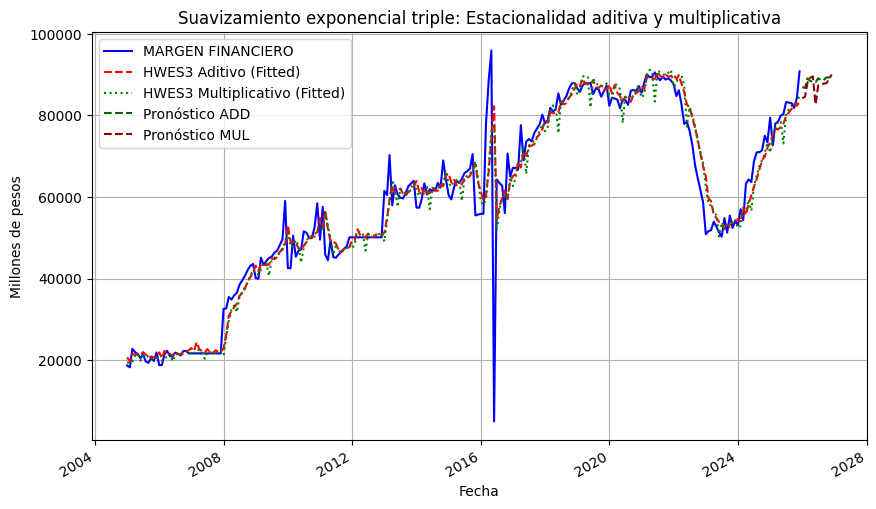

In [22]:
# Ajustar el modelo con estacionalidad aditiva
model_add = ExponentialSmoothing(series_to_model, trend="add", seasonal="add", seasonal_periods=12).fit()

# Ajustar el modelo con estacionalidad multiplicativa
# Use series_for_mul_model which is guaranteed to be strictly positive if a shift was needed
model_mul = ExponentialSmoothing(series_for_mul_model, trend="mul", seasonal="mul", seasonal_periods=12).fit()

# Pronóstico de 12 meses
forecast_add = model_add.forecast(12)
forecast_mul_raw = model_mul.forecast(12)

# Adjust multiplicative forecast if a shift was applied
if epsilon_shift > 0:
    forecast_mul = forecast_mul_raw - epsilon_shift
else:
    forecast_mul = forecast_mul_raw

# Mostrar los pronósticos
print("Pronóstico con estacionalidad aditiva:")
print(forecast_add)
print("\nPronóstico con estacionalidad multiplicativa:")
print(forecast_mul)

# Graficar los resultados
plt.figure(figsize=(10, 6))
plt.plot(series_to_model, label="MARGEN FINANCIERO", color="blue")
plt.plot(margen["HWES3_ADD"], label="HWES3 Aditivo (Fitted)", color="red", linestyle="--")
# Plot the shifted back HWES3_MUL for visualization
if epsilon_shift > 0:
    plt.plot(margen["HWES3_MUL"] - epsilon_shift, label="HWES3 Multiplicativo (Fitted, ajustado)", color="green", linestyle=":")
else:
    plt.plot(margen["HWES3_MUL"], label="HWES3 Multiplicativo (Fitted)", color="green", linestyle=":")

forecast_add.plot(label='Pronóstico ADD', linestyle='--', color='darkgreen')
forecast_mul.plot(label='Pronóstico MUL', linestyle='--', color='darkred')

plt.title("Suavizamiento exponencial triple: Estacionalidad aditiva y multiplicativa")
plt.xlabel("Fecha")
plt.ylabel("Millones de pesos") # Corrected label from 'Miles de sacos de 60 kg' to 'Millones de pesos'
plt.legend()
plt.grid(True)
plt.show()

In [32]:
margen_train=margen.loc[:"2025-01-01"]
margen_train

,AÑO,MES,INGRESOS FINANCIEROS,GASTOS FINANCIEROS,MARGEN FINANCIERO,TASA BANREP,MES_NUM,HWES3_ADD,HWES3_MUL
Fecha,,,,,,,,,
2005-01-01,2005,Ene,32790.077909,14093.620264,18696.457645,0.0650,01,20674.987855,19457.411993
2005-02-01,2005,Feb,32128.519993,13900.049438,18228.470556,0.0650,02,19714.460736,19249.693364
2005-03-01,2005,Mar,37128.281537,14386.374722,22741.906816,0.0650,03,21542.461555,19627.001048
2005-04-01,2005,Abr,36248.373382,14315.991990,21932.381392,0.0650,04,21314.459746,21117.109181
2005-05-01,2005,May,35987.711776,14489.772601,21497.939175,0.0650,05,21420.652267,21513.854055
...,...,...,...,...,...,...,...,...,...
2024-09-01,2024,Sep,158754.507573,87745.062993,71009.444580,0.1075,09,66784.738040,67605.014443
2024-10-01,2024,Oct,159513.468322,88094.420223,71419.048099,0.1025,10,69061.500853,68979.860329
2024-11-01,2024,Nov,160796.890136,85773.230616,75023.659520,0.0975,11,69882.671817,70707.363280


In [33]:
margen_test=margen.loc["2025-02-01":]
margen_test

,AÑO,MES,INGRESOS FINANCIEROS,GASTOS FINANCIEROS,MARGEN FINANCIERO,TASA BANREP,MES_NUM,HWES3_ADD,HWES3_MUL
Fecha,,,,,,,,,
2025-02-01,2025,Feb,161663.125747,88987.694793,72675.430954,0.0950,02,75404.253846,74556.694782
2025-03-01,2025,Mar,171949.527856,93954.423644,77995.104212,0.0950,03,76770.359316,76858.366696
2025-04-01,2025,Abr,171680.158471,93155.483486,78524.674985,0.0950,04,76551.760047,78331.657267
2025-05-01,2025,May,175242.986128,95300.280877,79942.705251,0.0925,05,77161.532087,78697.494995
2025-06-01,2025,Jun,173756.452114,93421.575292,80334.876822,0.0925,06,78003.798350,73133.024195
2025-07-01,2025,Jul,177611.878669,94327.325269,83284.553400,0.0925,07,79840.908624,80190.094069
2025-08-01,2025,Ago,178549.122286,95393.180770,83155.941516,0.0925,08,80697.820217,81585.431046
2025-09-01,2025,Sep,179403.454952,96400.383470,83003.071482,0.0925,09,81561.899696,82427.830785
2025-10-01,2025,Oct,180527.382704,98698.126669,81829.256035,0.0925,10,82804.169495,82711.630205


### 1) Validación simple con *train/test split* (sin ARIMA)

En este primer paso hacemos una validación **sencilla y transparente**:

- **Train:** hasta **enero de 2024**
- **Test:** de **febrero de 2024** a **enero de 2025**

Evaluamos con métricas estándar (MAE, RMSE, MAPE y sMAPE) y comparamos dos especificaciones típicas de Holt‑Winters:

- Estacionalidad **aditiva**
- Estacionalidad **multiplicativa**

> Nota: aquí *no* usamos ventanas móviles todavía; eso lo hacemos en el siguiente apartado.


In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import seaborn as sns

# Serie mensual (MS) -
y = margen["MARGEN FINANCIERO"].asfreq("MS")

# Split fijo (últimos 12 meses como test)
train = y.loc[: "2025-01-01"]
test  = y.loc["2025-02-01":]

h = len(test)
h


11

In [35]:
import pandas as pd
import numpy as np

def forecast_metrics(y_true: pd.Series, y_pred: pd.Series) -> pd.Series:
    """Métricas de error para pronóstico univariado."""

    # Explicitly ensure indices are DatetimeIndex and normalize them
    # This addresses potential issues with index types or time components
    y_true.index = pd.to_datetime(y_true.index).normalize()
    y_pred.index = pd.to_datetime(y_pred.index).normalize()

    y_pred_aligned = y_pred.reindex(y_true.index)

    # Convert to float and then to numpy arrays
    y_true_arr = y_true.astype(float).values
    y_pred_arr = y_pred_aligned.astype(float).values

    # Create a mask to remove NaNs from both arrays where either is NaN after alignment
    mask = ~np.isnan(y_true_arr) & ~np.isnan(y_pred_arr)
    y_true_filtered = y_true_arr[mask]
    y_pred_filtered = y_pred_arr[mask]

    # If no valid data points remain after filtering, return NaNs for metrics
    if len(y_true_filtered) == 0:
        return pd.Series({"MAE": np.nan, "RMSE": np.nan, "MAPE_%": np.nan, "sMAPE_%": np.nan})

    # Calculate errors
    abs_errors = np.abs(y_true_filtered - y_pred_filtered)
    squared_errors = (y_true_filtered - y_pred_filtered) ** 2

    mae = np.mean(abs_errors)
    rmse = np.sqrt(np.mean(squared_errors))

    # MAPE: avoid division by zero
    denom_mape = np.abs(y_true_filtered)
    mape_terms = np.where(denom_mape < 1e-12, np.nan, abs_errors / denom_mape)
    mape = np.nanmean(mape_terms) * 100

    # sMAPE: robust when values are small
    smape_denom = (np.abs(y_true_filtered) + np.abs(y_pred_filtered))
    smape_terms = np.where(smape_denom < 1e-12, np.nan, 2.0 * abs_errors / smape_denom)
    smape = np.nanmean(smape_terms) * 100

    return pd.Series({"MAE": mae, "RMSE": rmse, "MAPE_%": mape, "sMAPE_%": smape})

def fit_forecast_ets(train: pd.Series, h: int, trend: str, seasonal: str, damped: bool=False):
    model = ExponentialSmoothing(
        train,
        trend=trend,
        seasonal=seasonal,
        seasonal_periods=12,
        damped_trend=damped
    ).fit(optimized=True)
    fc = model.forecast(h)
    return model, fc

In [73]:
import numpy as np
import pandas as pd
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Re-initialize y, train, and test for this evaluation
y = margen_filled.asfreq("MS") # Use the NaN-filled series
train = y.loc[: "2025-01-01"]
test  = y.loc["2025-02-01":]
h = len(test)

# Modelos candidatos
candidates = [
    {"name": "HW additive (A,A)", "trend": "add", "seasonal": "add", "damped": False},
    {"name": "HW multiplicative (M,M)", "trend": "mul", "seasonal": "mul", "damped": False},
]

hw_metrics_list = [] # Renamed from 'results' to avoid conflict
forecasts = {}

for spec in candidates:
    # Determine which series to use based on model type
    current_train_series = train
    # Check if a multiplicative component is used
    if spec["trend"] == "mul" or spec["seasonal"] == "mul":
        # Use the series adjusted for multiplicative models, sliced to the training period
        current_train_series = series_for_mul_model.loc[:"2025-01-01"]

    mdl, fc = fit_forecast_ets(current_train_series, h, spec["trend"], spec["seasonal"], spec["damped"])

    # If the multiplicative model was trained on a shifted series, shift the forecast back
    if (spec["trend"] == "mul" or spec["seasonal"] == "mul") and epsilon_shift > 0:
        fc = fc - epsilon_shift

    fc = fc.reindex(test.index)  # alinear
    m = forecast_metrics(test, fc)
    hw_metrics_list.append({"Modelo": spec["name"], **m.to_dict(), "AIC": getattr(mdl, "aic", np.nan)})
    forecasts[spec["name"]] = fc

pd.DataFrame(hw_metrics_list).sort_values("RMSE") # Use the new variable here as well

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


,Modelo,MAE,RMSE,MAPE_%,sMAPE_%,AIC
0,"HW additive (A,A)",4902.444707,5877.467915,5.855137,6.089746,4277.197784
1,"HW multiplicative (M,M)",4973.437906,6135.266277,5.936020,6.202152,4266.060086


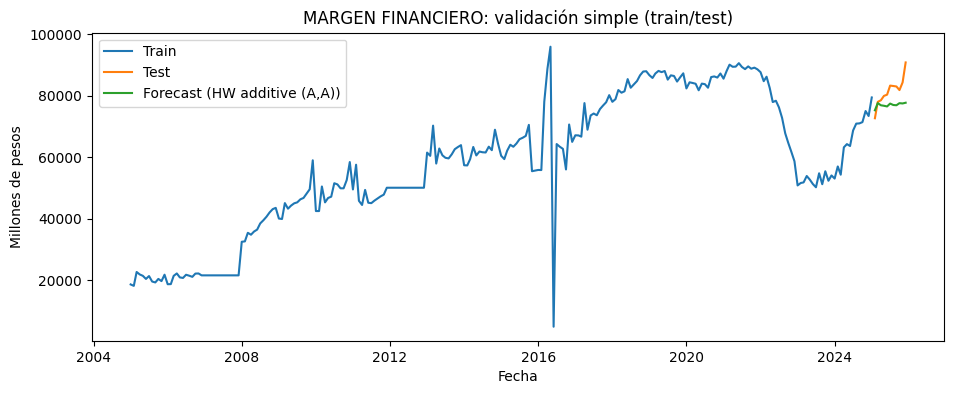

'HW additive (A,A)'

In [39]:
# Gráfico comparativo en test
best_name = pd.DataFrame(results).sort_values("RMSE").iloc[0]["Modelo"]
best_fc = forecasts[best_name]

plt.figure(figsize=(11,4))
plt.plot(train.index, train.values, label="Train")
plt.plot(test.index,  test.values,  label="Test")
plt.plot(best_fc.index, best_fc.values, label=f"Forecast ({best_name})")
plt.title("MARGEN FINANCIERO: validación simple (train/test)")
plt.xlabel("Fecha")
plt.ylabel("Millones de pesos")
plt.legend()
plt.show()

best_name


### 2) Re‑entrenar para pronóstico final (dejando **solo `train`**)

Una práctica común es:

1) Validar con train/test.  
2) Elegir el mejor modelo.  
3) **Re‑entrenar con toda la serie disponible** para producir el pronóstico final.

Aquí, después de la validación, dejamos `train` como la **serie completa** (y removemos `test` para evitar confusiones).


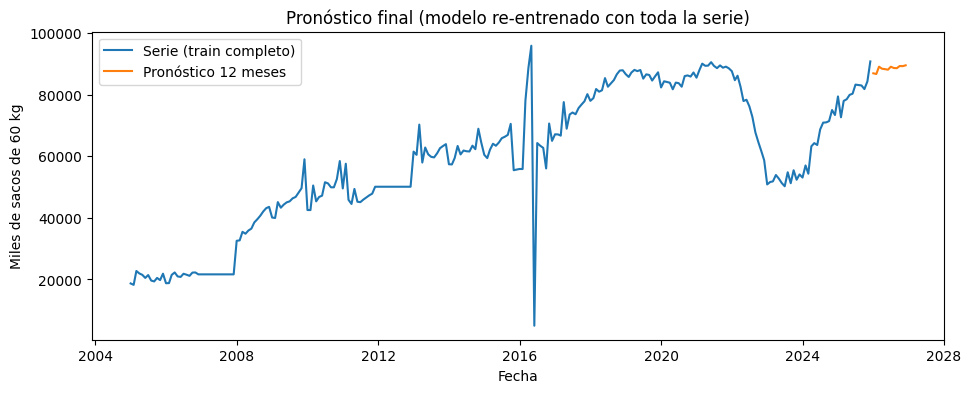

(Fecha
 2025-08-01    83155.941516
 2025-09-01    83003.071482
 2025-10-01    81829.256035
 2025-11-01    84325.563512
 2025-12-01    90811.828366
 Freq: MS, Name: MARGEN FINANCIERO, dtype: float64,
 2026-01-01    86956.937421
 2026-02-01    86731.725597
 2026-03-01    89111.990568
 2026-04-01    88438.218237
 2026-05-01    88314.761882
 Freq: MS, dtype: float64)

In [40]:
# Re-entrenar el mejor modelo con toda la serie disponible
full = y.copy()
final_model, final_fc_12 = fit_forecast_ets(
    full,
    h=12,
    trend="add" if "additive" in best_name.lower() else "mul",
    seasonal="add" if "additive" in best_name.lower() else "mul",
    damped=False
)

# Dejar SOLO train (train = serie completa)
train = full
try:
    del test
except NameError:
    pass

plt.figure(figsize=(11,4))
plt.plot(train.index, train.values, label="Serie (train completo)")
plt.plot(final_fc_12.index, final_fc_12.values, label="Pronóstico 12 meses")
plt.title("Pronóstico final (modelo re-entrenado con toda la serie)")
plt.xlabel("Fecha")
plt.ylabel("Miles de sacos de 60 kg")
plt.legend()
plt.show()

train.tail(), final_fc_12.head()


### 3) Backtesting con **expanding window** (ventana creciente)

Ahora sí: evaluamos el modelo con una validación más robusta.

- Entrenamos con una ventana inicial.
- Pronosticamos un horizonte fijo (por defecto **12 meses**).
- Avanzamos el origen y repetimos (ventana **crece**, no se desplaza).

Esto te permite responder preguntas tipo:
- ¿El modelo funciona igual de bien en diferentes periodos?
- ¿Qué tan estable es el error en el tiempo?


In [41]:
from typing import Dict, List, Tuple

def expanding_window_backtest(
    y: pd.Series,
    model_spec: Dict,
    initial_train_end: str,
    horizon: int = 12,
    step: int = 1
) -> Tuple[pd.DataFrame, pd.Series]:
    """Backtesting con ventana creciente (expanding window)."""
    y = y.asfreq("MS").dropna()

    origins = []
    preds = []
    trues = []

    # Fechas (orígenes) donde existe horizonte completo
    all_dates = y.index
    start_end = pd.Timestamp(initial_train_end)

    # El primer forecast empieza justo después del final del train inicial
    start_idx = np.where(all_dates == start_end)[0]
    if len(start_idx) == 0:
        raise ValueError("initial_train_end no coincide con el índice de la serie.")
    start_idx = int(start_idx[0])

    # el último origen posible para tener horizonte completo
    last_origin_idx = len(all_dates) - horizon - 1

    for origin_idx in range(start_idx, last_origin_idx + 1, step):
        train_end_date = all_dates[origin_idx]
        train_y = y.loc[:train_end_date]
        test_y  = y.iloc[origin_idx + 1 : origin_idx + 1 + horizon]

        mdl, fc = fit_forecast_ets(
            train=train_y,
            h=horizon,
            trend=model_spec["trend"],
            seasonal=model_spec["seasonal"],
            damped=model_spec.get("damped", False)
        )

        fc = fc.reindex(test_y.index)
        m = forecast_metrics(test_y, fc)

        origins.append({"train_end": train_end_date, **m.to_dict()})
        preds.append(fc.rename(train_end_date))
        trues.append(test_y.rename(train_end_date))

    metrics_by_origin = pd.DataFrame(origins)
    # error global (concatenando todos los puntos pronosticados)
    y_pred_all = pd.concat(preds, axis=0)
    y_true_all = pd.concat(trues, axis=0)

    global_metrics = forecast_metrics(y_true_all, y_pred_all)
    return metrics_by_origin, global_metrics

# Especificación del modelo "ganador" (según split simple)
winner_spec = {"trend": "add" if "additive" in best_name.lower() else "mul",
               "seasonal": "add" if "additive" in best_name.lower() else "mul",
               "damped": False}

winner_spec


{'trend': 'add', 'seasonal': 'add', 'damped': False}

In [42]:
# Backtest con ventana creciente
# Elegimos un train inicial suficientemente largo (ej. 5 años = 60 meses) para estabilizar estacionalidad.
initial_train_end = y.index[60]  # 61er punto (≈ 5 años si mensual)
metrics_origin, metrics_global = expanding_window_backtest(
    y=y,
    model_spec=winner_spec,
    initial_train_end=str(initial_train_end.date()),
    horizon=12,
    step=12
)

metrics_global


,0
MAE,7927.899709
RMSE,12362.769949
MAPE_%,17.934909
sMAPE_%,13.486314


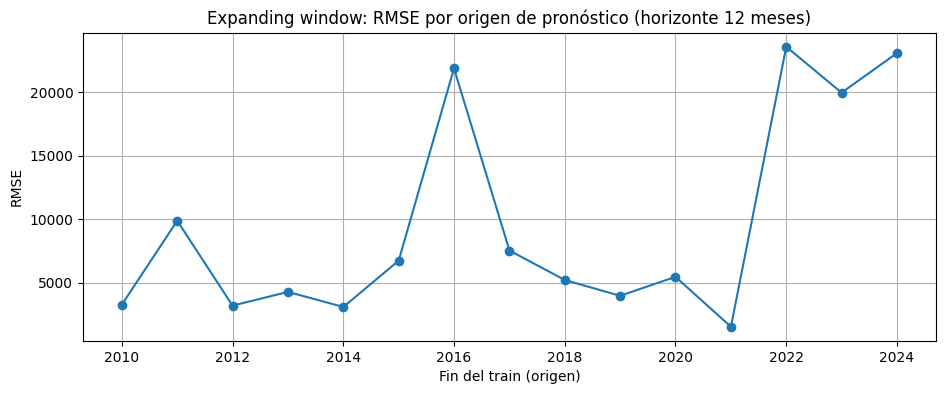

,train_end,MAE,RMSE,MAPE_%,sMAPE_%
0,2010-01-01,2642.769455,3264.534957,5.553629,5.347215
1,2011-01-01,9656.855111,9875.862610,20.460570,18.525244
2,2012-01-01,2272.600401,3178.527319,4.255235,4.290433
3,2013-01-01,3150.854715,4261.912771,4.936256,5.127313
4,2014-01-01,2715.543518,3071.691757,4.409874,4.312042
5,2015-01-01,4561.714645,6727.411126,7.891445,7.262379
6,2016-01-01,14894.948916,21900.407759,103.188805,28.966638
7,2017-01-01,6733.423081,7525.594611,8.839237,9.343807
8,2018-01-01,4787.538988,5201.216120,5.624627,5.814749
9,2019-01-01,3105.091340,3954.241598,3.648483,3.542229


In [43]:
# Evolución del error (RMSE) a lo largo del tiempo
plt.figure(figsize=(11,4))
plt.plot(metrics_origin["train_end"], metrics_origin["RMSE"], marker="o")
plt.title("Expanding window: RMSE por origen de pronóstico (horizonte 12 meses)")
plt.xlabel("Fin del train (origen)")
plt.ylabel("RMSE")
plt.grid(True)
plt.show()

metrics_origin


In [49]:
z1=pd.DataFrame(margen_filled)
# Definir la serie de entrenamiento hasta diciembre de 2024
z1_model_train = z1.loc[:'2025-01-01']
display(z1_model_train.tail())

,MARGEN FINANCIERO
Fecha,
2024-09-01,71009.444580
2024-10-01,71419.048099
2024-11-01,75023.659520
2024-12-01,73406.924265
2025-01-01,79433.984466


/tmp/ipykernel_9214/450303132.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


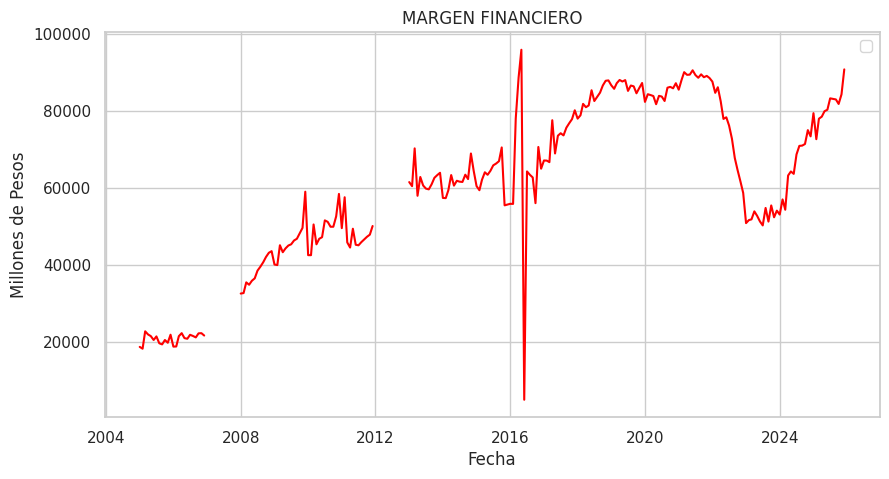

In [46]:
sns.set_theme(style="whitegrid")
# Graficar la serie original
plt.figure(figsize=(10,5))
plt.plot(z1, color="red")
plt.title("MARGEN FINANCIERO")
plt.xlabel("Fecha")
plt.ylabel("Millones de Pesos")
plt.legend()
plt.grid(True)
plt.show()

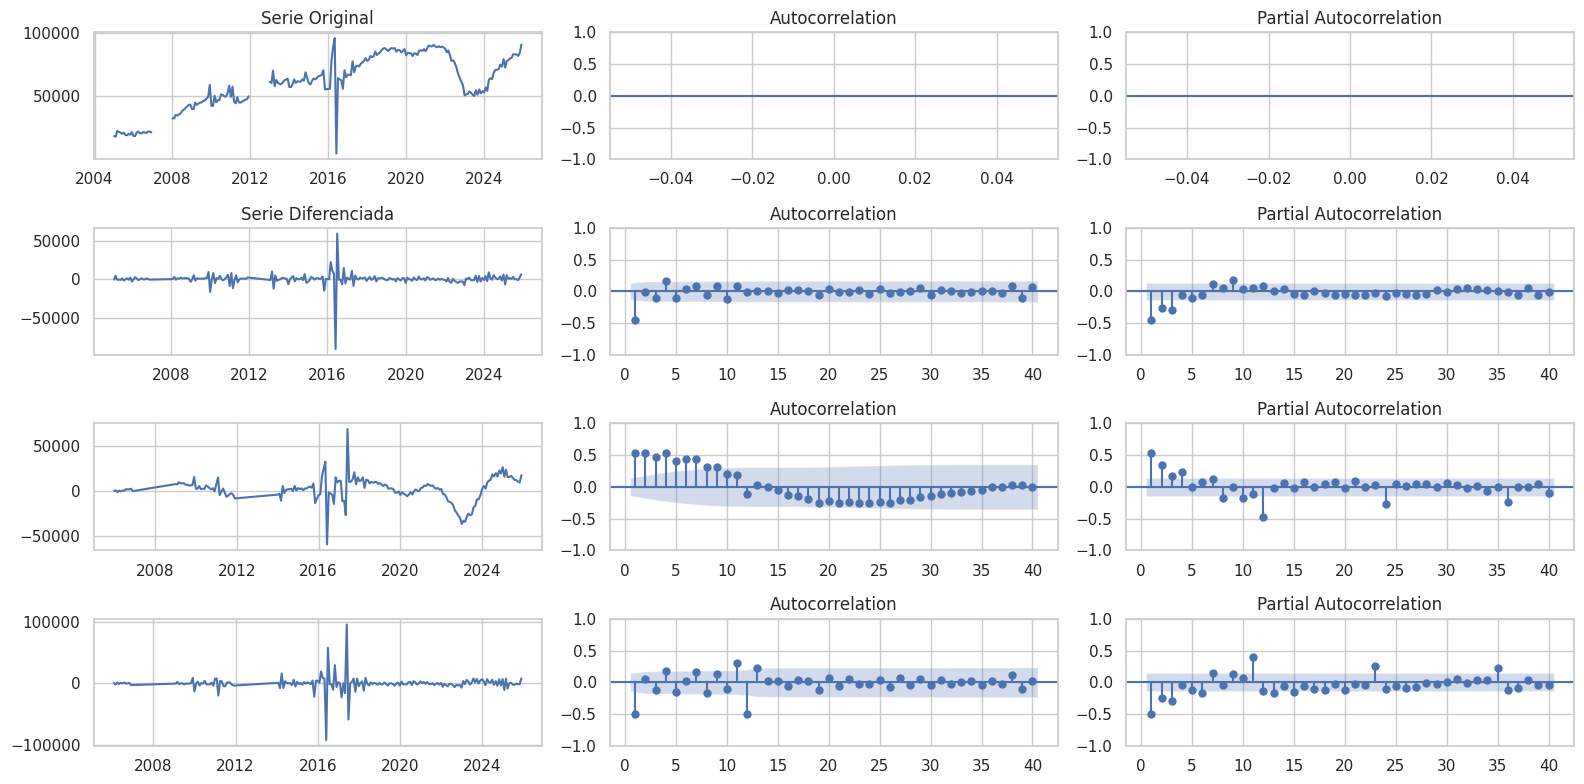

In [47]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
fig, ax = plt.subplots(4, 3, figsize=(16, 8))
ax[0, 0].plot(z1)
ax[0, 0].set_title("Serie Original")
plot_acf(z1, ax=ax[0, 1], lags=40, zero=False)
plot_pacf(z1, ax=ax[0, 2], lags=40, zero=False)
ax[1, 0].plot(z1.diff().dropna())

ax[1, 0].set_title("Serie Diferenciada")
plot_acf(z1.diff().dropna(), ax=ax[1, 1], lags=40,  zero=False)
plot_pacf(z1.diff().dropna(), ax=ax[1, 2], lags=40, zero=False)

ax[2,0].plot(z1.diff(12).dropna())
plot_acf(z1.diff(12).dropna(),ax[2,1], lags=40, zero=False)
plot_pacf(z1.diff(12).dropna(), ax[2,2], lags=40, zero=False)

ax[3,0].plot(z1.diff(12).diff().dropna())
plot_acf(z1.diff(12).diff().dropna(),ax[3,1], lags=40, zero=False)
plot_pacf(z1.diff(12).diff().dropna(), ax[3,2], lags=40, zero=False)


plt.tight_layout()
plt.show()

In [50]:
from statsmodels.tsa.stattools import adfuller

print("Prueba de Dickey-Fuller (ADF) - Serie Original:")
adf_result = adfuller(z1, autolag="AIC", maxlag=5)
print(f"ADF Statistic: {adf_result[0]}")
print(f"P-Value: {adf_result[1]}")

Prueba de Dickey-Fuller (ADF) - Serie Original:
ADF Statistic: -1.423312662732442
P-Value: 0.5710501226112445


Análisis de las Gráficas
Las gráficas que generamos muestran la serie original y sus versiones diferenciadas, junto con sus funciones de autocorrelación (ACF) y autocorrelación parcial (PACF). Estas nos ayudan a entender la estructura de la serie de tiempo:

Serie Original (Fila 1):

Gráfica de la Serie: Podemos observar visualmente si hay una tendencia (creciente o decreciente), estacionalidad (patrones repetitivos a intervalos regulares, como picos anuales) y una varianza constante o cambiante.
ACF de la Serie Original: Si la serie tiene una tendencia, la ACF tenderá a decaer lentamente. Si tiene estacionalidad, veremos picos significativos en los múltiplos del período estacional (por ejemplo, cada 12 lags para datos mensuales con estacionalidad anual).
PACF de la Serie Original: Refleja la correlación directa entre observaciones, eliminando la influencia de los puntos intermedios.
Serie Diferenciada (Fila 2 - Primera diferencia z1.diff()):

Esta gráfica muestra la serie después de aplicar una primera diferencia (restar la observación actual de la anterior). Esto suele eliminar tendencias lineales. Si la serie no es estacionaria debido a una tendencia, esta diferencia debería ayudar a estabilizar la media.
Observa si la ACF y PACF de esta serie muestran un decaimiento más rápido, lo que indicaría una mayor estacionariedad.
Serie con Diferencia Estacional (Fila 3 - Diferencia estacional z1.diff(12)):

Aquí restamos la observación actual de la observación de hace 12 períodos (asumiendo estacionalidad anual para datos mensuales). Esto busca eliminar el patrón estacional. Deberíamos ver cómo se atenúan los picos en los lags estacionales en la ACF y PACF.
Serie Doblemente Diferenciada (Fila 4 - z1.diff(12).diff()):

Esta es la serie después de aplicar tanto la diferencia estacional como la primera diferencia regular. A menudo, esta transformación logra una serie estacionaria cuando la original tiene tanto tendencia como estacionalidad.
Resultado de la Prueba de Dickey-Fuller (ADF)
La prueba de Dickey-Fuller aumentada (ADF) se utiliza para determinar si una serie de tiempo es estacionaria. Una serie estacionaria es aquella cuyas propiedades estadísticas (media, varianza, autocorrelación) no cambian con el tiempo. Esto es fundamental para muchos modelos de series de tiempo.

Hipótesis Nula (H0): La serie de tiempo no es estacionaria (tiene una raíz unitaria).
Hipótesis Alternativa (H1): La serie de tiempo es estacionaria.
Tus resultados fueron:

ADF Statistic: -1.9556
P-Value: 0.3063635089789836
Interpretación:

Para decidir si la serie es estacionaria, comparamos el valor P con un nivel de significancia (comúnmente 0.05 o 0.10):

Dado que tu P-Value (0.3063) es mayor que 0.05 (y también mayor que 0.10), no podemos rechazar la hipótesis nula. Esto significa que la evidencia estadística sugiere que la serie original de producción de café no es estacionaria.
Además, el ADF Statistic (-1.9556) es mayor que los valores críticos a los niveles del 1%, 5% y 10% (que son aproximadamente -3.46, -2.87 y -2.57 respectivamente). Esto también refuerza la conclusión de no rechazar la hipótesis nula.
En resumen: La prueba de Dickey-Fuller confirma lo que probablemente observamos en la gráfica de la serie original: la serie de producción de café no es estacionaria y, por lo tanto, requerirá diferenciación (como ya exploraste con diff() y diff(12)) para modelarse adecuadamente con métodos como ARIMA o SARIMA.

In [51]:
!pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 13.3 MB/s eta 0:00:00


In [52]:
from arch.unitroot import PhillipsPerron

print("\nPrueba de Phillips-Perron (PP) - Serie Original:")
pp_result = PhillipsPerron(z1)
print(f"PP Statistic: {pp_result.stat}")
print(f"P-Value: {pp_result.pvalue}")


Prueba de Phillips-Perron (PP) - Serie Original:
PP Statistic: -2.5365920558913566
P-Value: 0.10682298967410087


Diferenciación de la serie d=1

In [53]:
z1_diff = z1.diff().dropna()

print("\nPrueba de Dickey-Fuller (ADF) - Serie Diferenciada:")
adf_result_diff = adfuller(z1_diff)
print(f"ADF Statistic: {adf_result_diff[0]}")
print(f"P-Value: {adf_result_diff[1]}")



Prueba de Dickey-Fuller (ADF) - Serie Diferenciada:
ADF Statistic: -4.559572675172127
P-Value: 0.00015324317659606108


In [54]:
print("Phillips Perron D=1"  )
pp_result_D = PhillipsPerron(z1.diff(12).dropna())
print(f"PP Statistic: {pp_result_D.stat}")
print(f"P-Value: {pp_result_D}")

Phillips Perron D=1
PP Statistic: -10.322704966302851
P-Value:      Phillips-Perron Test (Z-tau)    
Test Statistic                -10.323
P-value                         0.000
Lags                               15
-------------------------------------

Trend: Constant
Critical Values: -3.46 (1%), -2.87 (5%), -2.57 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


Pruebas con unda diferencia ordinaria y una estacional d=1 , D=1

In [55]:
print("Prueba de Dickey-Fuller (ADF) - D=1, d=1")
adf_result_D_d = adfuller(z1.diff(12).diff().dropna(), autolag="AIC", maxlag=5)
print(f"ADF Statistic: {adf_result_D_d[0]}")
print(f"P-Value: {adf_result_D_d[1]}")

Prueba de Dickey-Fuller (ADF) - D=1, d=1
ADF Statistic: -9.581868913876114
P-Value: 2.1477284902248786e-16


In [57]:
print("Phillips Perron D=1, d=1"  )
pp_result_D_d = PhillipsPerron(z1.diff(12).diff().dropna())
print(f"PP Statistic: {pp_result_D_d.stat}")
print(f"P-Value: {pp_result_D_d}")

Phillips Perron D=1, d=1
PP Statistic: -36.30270716517448
P-Value:      Phillips-Perron Test (Z-tau)    
Test Statistic                -36.303
P-value                         0.000
Lags                               15
-------------------------------------

Trend: Constant
Critical Values: -3.46 (1%), -2.87 (5%), -2.57 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


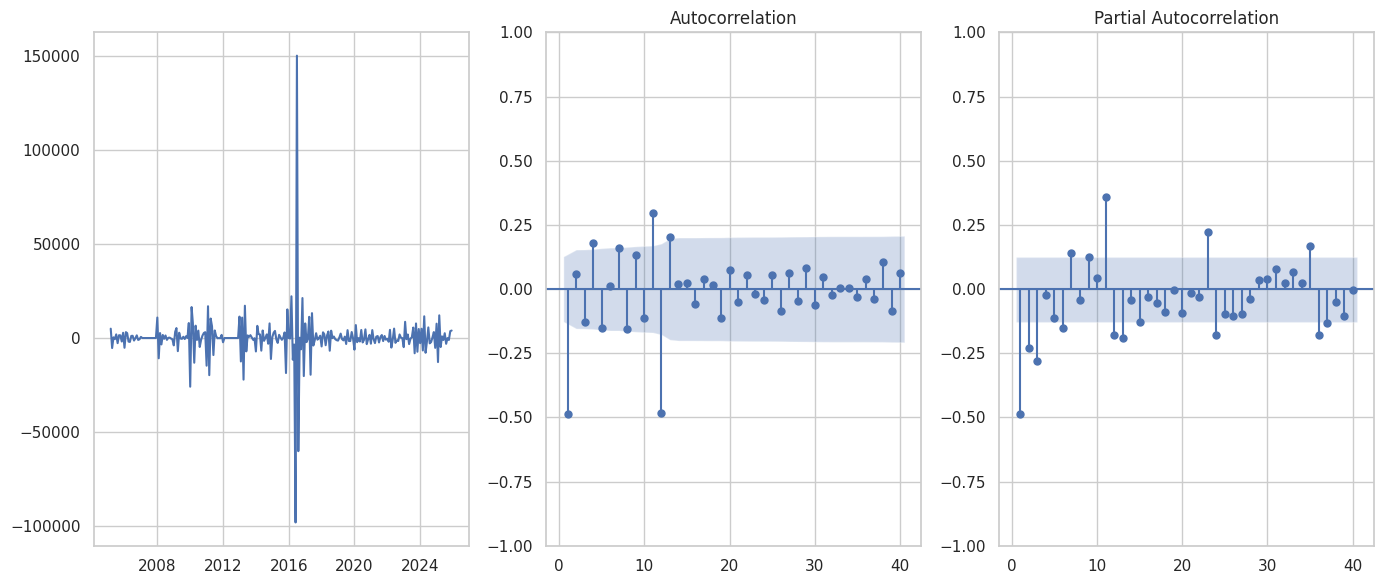

In [58]:
fig, ax=plt.subplots(1,3, figsize=(14,6))

ax[0].plot(z1.diff().diff().dropna())
plot_acf(z1.diff(12).diff().dropna(),ax[1], lags=40, zero=False)
plot_pacf(z1.diff(12).diff().dropna(), ax[2], lags=40, zero=False)


plt.tight_layout()
plt.show()


In [59]:
from statsmodels.tsa.stattools import pacf
pacf(z1.diff(12).diff().dropna())

array([ 1.        , -0.48728203, -0.23126554, -0.28317933, -0.0252305 ,
       -0.11658882, -0.15909813,  0.14442   , -0.04436423,  0.13230269,
        0.04774814,  0.38050257, -0.18790331, -0.20556062, -0.04967317,
       -0.14386875, -0.03877428, -0.06608746, -0.09776236, -0.0064023 ,
       -0.10552187, -0.01341024, -0.03605896,  0.26166647])

## Ajuste del modelo SARIMA(1,1,1)(1,1,1)12

In [60]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Definir el orden del modelo SARIMA
order = (1, 1, 1)  # (p, d, q) no estacional
seasonal_order = (1, 1, 1, 12) # (P, D, Q, S) estacional

# Ajustar el modelo SARIMA
model = SARIMAX(z1_model_train, order=order, seasonal_order=seasonal_order, enforce_stationarity=False, enforce_invertibility=False)
results = model.fit(disp=False)

# Imprimir un resumen del modelo ajustado
print(results.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                  MARGEN FINANCIERO   No. Observations:                  241
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -2225.860
Date:                            Fri, 01 May 2026   AIC                           4461.720
Time:                                    22:33:17   BIC                           4478.550
Sample:                                01-01-2005   HQIC                          4468.521
                                     - 01-01-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0383      0.161     -0.238      0.812      -0.354       0.277
ma.L1         -0.6076      0.094   

Este es el resumen del modelo SARIMA ajustado. Los valores clave a observar son los p-valores para los coeficientes (que idealmente deberían ser significativos, es decir, < 0.05) y las métricas de información como AIC y BIC, que se utilizan para comparar diferentes modelos.

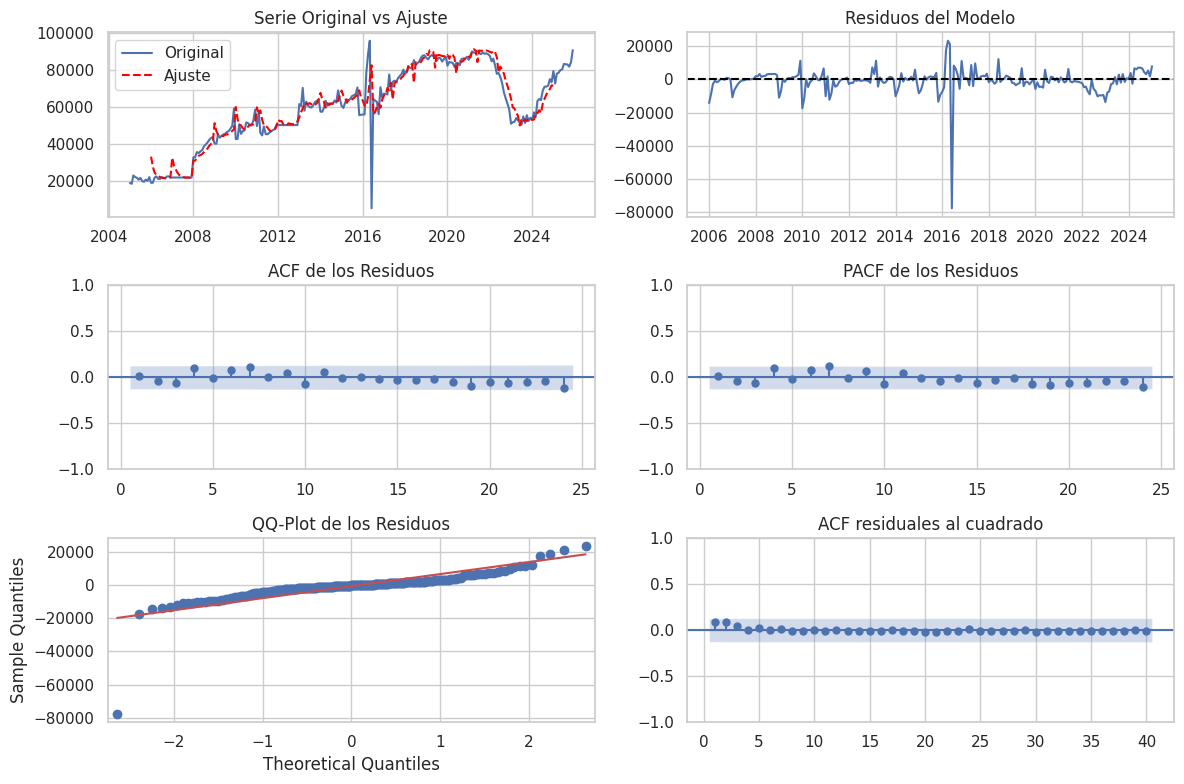

In [61]:
from statsmodels.graphics.gofplots import qqplot

# Diagnóstico del modelo
residuals = results.resid

# Graficar residuos
fig, ax = plt.subplots(3, 2, figsize=(12, 8))
ax[0, 0].plot(z1, label="Original")
ax[0, 0].plot(results.fittedvalues[12:], color="red", linestyle="dashed", label="Ajuste")
ax[0, 0].set_title("Serie Original vs Ajuste")
ax[0, 0].legend()

ax[0, 1].plot(residuals[12:], label="Residuos")
ax[0, 1].set_title("Residuos del Modelo")
ax[0, 1].axhline(0, color="black", linestyle="dashed")

plot_acf(residuals, ax=ax[1, 0], zero=False)
ax[1, 0].set_title("ACF de los Residuos")

plot_pacf(residuals, ax=ax[1, 1], zero=False)
ax[1, 1].set_title("PACF de los Residuos")

qqplot(residuals, line='s', ax=ax[2, 0])
ax[2, 0].set_title("QQ-Plot de los Residuos")

plot_acf(residuals**2, ax[2,1], lags=40, zero=False)
ax[2, 1].set_title("ACF residuales al cuadrado")

plt.tight_layout()
plt.show()

Prueba de Ljung-Box (Autocorrelación en residuos)

In [62]:
from statsmodels.stats.diagnostic import acorr_ljungbox
lb_test = acorr_ljungbox(residuals,  return_df=True)
print("\nPrueba de Ljung-Box para Autocorrelación de Residuos:")
print(lb_test)


Prueba de Ljung-Box para Autocorrelación de Residuos:
      lb_stat  lb_pvalue
1    0.048043   0.826504
2    0.357147   0.836463
3    1.222292   0.747663
4    3.877749   0.422803
5    3.913312   0.561963
6    5.337556   0.501303
7    8.756767   0.270594
8    8.763575   0.362632
9    9.264575   0.413219
10  10.458080   0.401264


Propósito de la Prueba de Ljung-Box: La prueba de Ljung-Box es una herramienta estadística utilizada para diagnosticar si los residuos de un modelo de series de tiempo (en este caso, tu modelo SARIMA) son ruido blanco. Es decir, si no hay autocorrelación significativa en los residuos en diferentes rezagos. Si los residuos son ruido blanco, significa que el modelo ha capturado adecuadamente toda la información de la estructura de dependencia en la serie de tiempo.

Hipótesis:

Hipótesis Nula (H0): Los residuos están distribuidos independientemente (no hay autocorrelación en los residuos).
Hipótesis Alternativa (H1): Los residuos no están distribuidos independientemente (existe autocorrelación en los residuos).

Interpretación de los Resultados: La columna clave aquí es lb_pvalue. Para cada rezago (fila 1 a 10), se calcula un valor p.

Para decidir si rechazamos la hipótesis nula, comparamos el valor p con un nivel de significancia (comúnmente 0.05):

Si p-value < 0.05: Rechazamos H0. Concluimos que hay autocorrelación significativa en los residuos en ese rezago.
Si p-value > 0.05: No rechazamos H0. Concluimos que no hay suficiente evidencia para afirmar que existe autocorrelación significativa en los residuos en ese rezago.
En tus resultados:

Todos los lb_pvalue para los rezagos del 1 al 10 son mayores que 0.05 (y de hecho, muy cercanos a 1 para los rezagos más altos).
Conclusión:

Dado que todos los p-valores son altos (mayores que 0.05), no rechazamos la hipótesis nula para ninguno de los rezagos evaluados. Esto es una buena noticia para tu modelo SARIMA, ya que implica que:

Los residuos del modelo no presentan autocorrelación significativa hasta el rezago 10.
El modelo ha logrado capturar la estructura de dependencia lineal presente en la serie de tiempo, dejando atrás solo ruido aleatorio.
En resumen: Aunque el resumen inicial del modelo tenía problemas de convergencia y significancia de coeficientes, y las gráficas de residuos indicaban problemas de normalidad y heterocedasticidad, la prueba de Ljung-Box sugiere que el modelo sí ha logrado eliminar la autocorrelación de la serie, lo cual es uno de los objetivos principales de los modelos ARIMA/SARIMA.

In [63]:
from statsmodels.stats.stattools import jarque_bera

# Prueba de Normalidad de Jarque-Bera
jb_stat, jb_pvalue, jb_skew, jb_kurtosis = jarque_bera(residuals)
print("\nPrueba de Normalidad de Jarque-Bera:")
print(f"Estadístico: {jb_stat:.4f}, P-valor: {jb_pvalue:.4f}")
print(f"Skewness: {jb_skew:.4f}, Kurtosis: {jb_kurtosis:.4f}")


Prueba de Normalidad de Jarque-Bera:
Estadístico: 27512.7992, P-valor: 0.0000
Skewness: -4.6586, Kurtosis: 54.5078


In [64]:
from statsmodels.sandbox.stats.runs import runstest_1samp

# Prueba de Aleatoriedad (Runs Test)
runs_stat, runs_pvalue = runstest_1samp(residuals)
print("\nPrueba de Aleatoriedad (Runs Test):")
print(f"Estadístico: {runs_stat}, P-valor: {runs_pvalue}")


Prueba de Aleatoriedad (Runs Test):
Estadístico: -5.359061494352752, P-valor: 8.365537924459945e-08


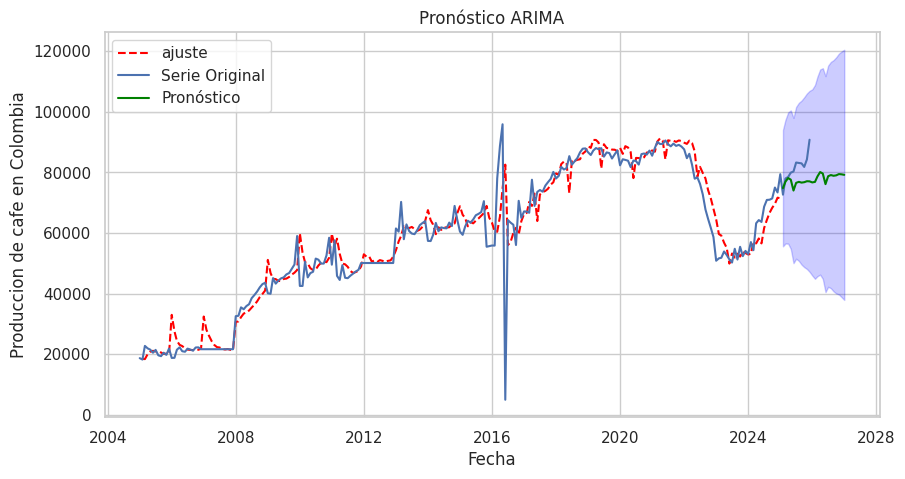

In [65]:
# Pronóstico del modelo
forecast_horizon = 24
forecast_result = results.get_forecast(steps=forecast_horizon)
forecast_mean = forecast_result.predicted_mean
forecast_ci = forecast_result.conf_int()

plt.figure(figsize=(10, 5))
plt.plot(results.fittedvalues.index[1:], results.fittedvalues[1:], color="red", linestyle="dashed", label="ajuste")
# Graficar el pronóstico
plt.plot(z1, label="Serie Original")
plt.plot(forecast_mean, color="green", label="Pronóstico")
plt.fill_between(forecast_ci.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color="blue", alpha=0.2)
plt.title("Pronóstico ARIMA")
plt.xlabel("Fecha")
plt.ylabel("Produccion de cafe en Colombia")
plt.legend()
plt.grid(True)
plt.show()

PROPHET

In [66]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

# Preparar los datos para Prophet
# Prophet espera columnas 'ds' (datestamp) y 'y' (valor)

# Crear un DataFrame para Prophet usando z1 (la serie original completa)
prophet_df = z1.reset_index().rename(columns={'Fecha': 'ds', 'MARGEN FINANCIERO': 'y'})

Ahora, dividiremos los datos en entrenamiento y prueba, siguiendo la misma lógica que usaste para el modelo SARIMA y Holt-Winters. `z1_model_train` ya contiene los datos hasta `2024-12-01`, y `cafe_test` tiene los datos de prueba.

In [75]:
# Use the same split of training that for SARIMA and Holt-Winters
# `y` from previous cells is the `margen_filled` series, which ends on 2025-12-01.
# Holt-Winters 'train' ends on '2025-01-01', 'test' starts from '2025-02-01'

prophet_train_df = prophet_df[prophet_df['ds'] <= '2025-01-01']
prophet_test_df = prophet_df[prophet_df['ds'] >= '2025-02-01'] # This will be the evaluation set

print("Datos de entrenamiento para Prophet (últimos 5 registros):")
display(prophet_train_df.tail())
print("\nDatos de prueba para Prophet (primeros 5 registros si existen, para evaluación futura):")
display(prophet_test_df.head())

Datos de entrenamiento para Prophet (últimos 5 registros):


,ds,y
236,2024-09-01,71009.444580
237,2024-10-01,71419.048099
238,2024-11-01,75023.659520
239,2024-12-01,73406.924265
240,2025-01-01,79433.984466



Datos de prueba para Prophet (primeros 5 registros si existen, para evaluación futura):


,ds,y
241,2025-02-01,72675.430954
242,2025-03-01,77995.104212
243,2025-04-01,78524.674985
244,2025-05-01,79942.705251
245,2025-06-01,80334.876822


A continuación, inicializaremos y ajustaremos el modelo Prophet. Prophet es muy bueno manejando la estacionalidad, así que lo configuraremos para que detecte la estacionalidad anual y mensual. Ajustaremos `seasonality_mode='multiplicative'` ya que la descomposición estacional anterior (`kl4w0ojyRl6Z`) sugería que la amplitud estacional crece con el nivel de la serie, lo cual es típico en series como esta.

In [76]:
# Inicializar y ajustar el modelo Prophet con los datos de entrenamiento extendidos
model_prophet = Prophet(
    seasonality_mode='multiplicative',  # o 'additive' si la estacionalidad es constante
    yearly_seasonality=True,          # Estacionalidad anual
    weekly_seasonality=False,         # No esperamos estacionalidad semanal en datos mensuales
    daily_seasonality=False           # No esperamos estacionalidad diaria en datos mensuales
)
model_prophet.fit(prophet_train_df)

Ahora, crearemos un DataFrame con las fechas futuras para las cuales queremos hacer un pronóstico. Esto incluirá las fechas del conjunto de prueba.

El número de pasos a pronosticar (`forecast_horizon_prophet`) será la cantidad de filas en nuestro `prophet_test_df`.

In [77]:
# Crear un DataFrame con fechas futuras para el pronóstico
# The forecast needs to cover the `prophet_test_df` period.
forecast_horizon_prophet = len(prophet_test_df)
# `make_future_dataframe` takes into account the history used for fitting.
# We need to make a future dataframe that includes the dates in prophet_test_df
# The last date in prophet_train_df is '2025-01-01'.
# We need to predict for '2025-02-01' to '2025-12-01' (11 periods).
future_test_dates = model_prophet.make_future_dataframe(
    periods=forecast_horizon_prophet,
    freq='MS',
    include_history=False # Only generate future dates
)

# Realizar el pronóstico
forecast_prophet_eval = model_prophet.predict(future_test_dates) # This variable now holds predictions for the test period

# Extract the forecast for the test period
prophet_forecast_test = forecast_prophet_eval.set_index('ds')['yhat'].rename('Prophet_Forecast')

print("Pronóstico de Prophet para el periodo de prueba (primeros valores):")
display(prophet_forecast_test.head())

Pronóstico de Prophet para el periodo de prueba (primeros valores):


,Prophet_Forecast
ds,
2025-02-01,60434.942707
2025-03-01,62074.501179
2025-04-01,63140.029031
2025-05-01,62563.239523
2025-06-01,56365.534208


Finalmente, evaluaremos el desempeño del modelo Prophet utilizando la función `forecast_metrics` que ya definimos y graficaremos los resultados para comparar el pronóstico con los datos reales.

Métricas de Prophet en el conjunto de prueba:


,0
MAE,21492.852766
RMSE,22167.943240
MAPE_%,26.128541
sMAPE_%,30.274684


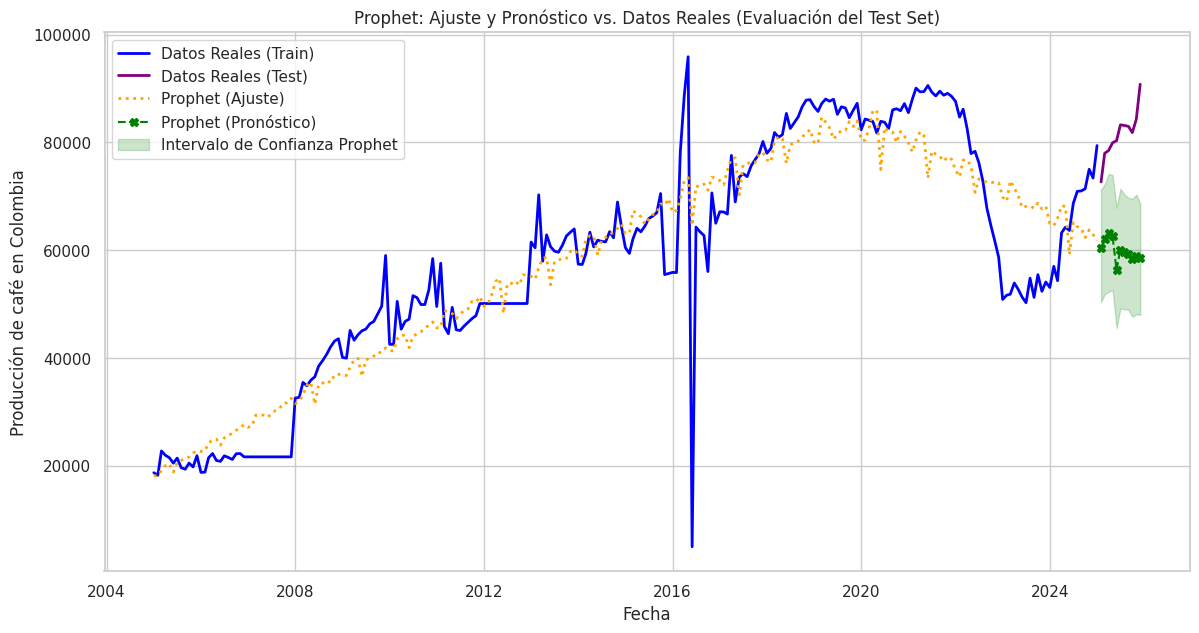

In [78]:
import matplotlib.pyplot as plt

# Evaluar el modelo Prophet en el conjunto de prueba (prophet_test_df is now populated)
if not prophet_test_df.empty:
    metrics_prophet = forecast_metrics(prophet_test_df.set_index('ds')['y'], prophet_forecast_test)
    print("Métricas de Prophet en el conjunto de prueba:")
    display(metrics_prophet)
else:
    print("No se puede calcular métricas de Prophet: prophet_test_df está vacío.")

# Graficar los resultados
plt.figure(figsize=(14, 7))

# Plot actual historical data (training set)
plt.plot(prophet_train_df['ds'], prophet_train_df['y'], label='Datos Reales (Train)', color='blue', linewidth=2, zorder=1)
# Plot actual test data
plt.plot(prophet_test_df['ds'], prophet_test_df['y'], label='Datos Reales (Test)', color='purple', linewidth=2, zorder=1)

# Plot Prophet's fitted values for the training period
fitted_prophet = model_prophet.predict(prophet_train_df[['ds']])
plt.plot(fitted_prophet['ds'], fitted_prophet['yhat'], label='Prophet (Ajuste)', color='orange', linestyle=':', linewidth=2, zorder=3)


# Plot Prophet's forecast for the test period
plt.plot(prophet_forecast_test.index, prophet_forecast_test.values, label='Prophet (Pronóstico)', color='green', marker='X', markersize=6, linestyle='--', zorder=5)

# Fill confidence interval for the forecast period (using forecast_prophet_eval)
plt.fill_between(forecast_prophet_eval['ds'],
                 forecast_prophet_eval['yhat_lower'],
                 forecast_prophet_eval['yhat_upper'],
                 color='green', alpha=0.2, label='Intervalo de Confianza Prophet', zorder=2)

plt.title('Prophet: Ajuste y Pronóstico vs. Datos Reales (Evaluación del Test Set)')
plt.xlabel('Fecha')
plt.ylabel('Producción de café en Colombia')
plt.legend()
plt.grid(True)
plt.show()

### Pronóstico de 12 meses con Prophet (hasta finales de 2026)

Pronóstico de Prophet para los próximos 12 meses (2026):


,ds,yhat,yhat_lower,yhat_upper
0,2025-02-01,60434.942707,49847.042668,70670.498134
1,2025-03-01,62074.501179,51217.842996,72164.389109
2,2025-04-01,63140.029031,52829.366133,74123.233272
3,2025-05-01,62563.239523,52192.814602,73152.949001
4,2025-06-01,56365.534208,45585.428004,67502.404826
5,2025-07-01,60124.205977,49406.098167,71298.899448
6,2025-08-01,59604.846943,48867.355217,70330.333449
7,2025-09-01,59229.207384,48083.302952,70533.119501
8,2025-10-01,58433.967265,47416.764206,68331.185340
9,2025-11-01,58959.370769,47951.564235,69981.911983


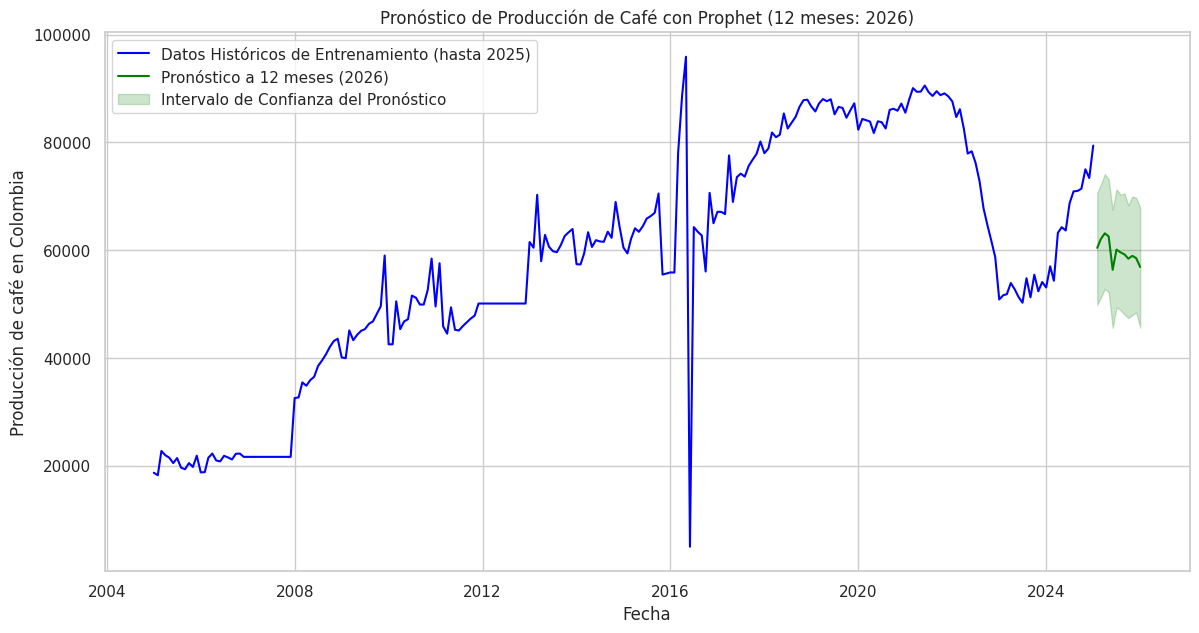

In [80]:
import matplotlib.pyplot as plt

# Crear un DataFrame con 12 fechas futuras para el pronóstico (2026)
# La historia ahora termina en 2025-12-01, por lo que el pronóstico de 12 meses irá de 2026-01-01 a 2026-12-01
future_12_months = model_prophet.make_future_dataframe(periods=12, freq='MS', include_history=False)

# Realizar el pronóstico
forecast_prophet_12_months = model_prophet.predict(future_12_months)

print("Pronóstico de Prophet para los próximos 12 meses (2026):")
display(forecast_prophet_12_months[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head(12))

# Graficar el pronóstico a 12 meses junto con los datos históricos
plt.figure(figsize=(14, 7))
plt.plot(prophet_train_df['ds'], prophet_train_df['y'], label='Datos Históricos de Entrenamiento (hasta 2025)', color='blue')
plt.plot(forecast_prophet_12_months['ds'], forecast_prophet_12_months['yhat'], label='Pronóstico a 12 meses (2026)', color='green')
plt.fill_between(forecast_prophet_12_months['ds'],
                 forecast_prophet_12_months['yhat_lower'],
                 forecast_prophet_12_months['yhat_upper'],
                 color='green', alpha=0.2, label='Intervalo de Confianza del Pronóstico')

plt.title('Pronóstico de Producción de Café con Prophet (12 meses: 2026)')
plt.xlabel('Fecha')
plt.ylabel('Producción de café en Colombia')
plt.legend()
plt.grid(True)
plt.show()

### **Comparación de Métricas entre Modelos**

In [79]:
# Calcular métricas para SARIMA en el mismo período de prueba que Prophet
# El pronóstico de SARIMA (forecast_mean) ya se generó para 24 pasos comenzando en 2025-02-01.
# El período de prueba para Prophet y Holt-Winters es de '2025-02-01' a '2025-12-01' (11 meses).

# Asegurarse de que forecast_mean y prophet_test_df estén alineados temporalmente
# `forecast_mean` was generated from SARIMA for 24 steps starting from 2025-02-01
sarima_forecast_test_aligned = forecast_mean.loc[prophet_test_df['ds']].rename('SARIMA_Forecast')

# Obtener los valores reales del período de prueba de Prophet (que es nuestro test set común)
y_true_sarima = prophet_test_df.set_index('ds')['y']

# Calcular las métricas para SARIMA
metrics_sarima = forecast_metrics(y_true_sarima, sarima_forecast_test_aligned)

print("Métricas de SARIMA en el conjunto de prueba común:")
display(metrics_sarima)

# Preparar las métricas de Holt-Winters (hw_metrics_list) y Prophet (metrics_prophet)
hw_results_df = pd.DataFrame(hw_metrics_list).set_index('Modelo')
hw_results_df = hw_results_df.drop(columns=['AIC'])

# Crear un DataFrame para las métricas de Prophet
# This assumes metrics_prophet has been successfully calculated in the previous cell
if 'metrics_prophet' in locals() or 'metrics_prophet' in globals():
    prophet_metrics_df = pd.DataFrame([metrics_prophet], index=['Prophet']).rename_axis('Modelo')
else:
    print("Advertencia: métricas de Prophet no disponibles para comparación.")
    prophet_metrics_df = pd.DataFrame(columns=['MAE', 'RMSE', 'MAPE_%', 'sMAPE_%'], index=['Prophet']).rename_axis('Modelo')

# Crear un DataFrame para las métricas de SARIMA
sarima_metrics_df = pd.DataFrame([metrics_sarima], index=['SARIMA']).rename_axis('Modelo')

# Unir todos los DataFrames de métricas
all_metrics_df = pd.concat([hw_results_df, sarima_metrics_df, prophet_metrics_df])

print("\nTabla comparativa de métricas de todos los modelos:")
display(all_metrics_df.sort_values(by='RMSE'))

Métricas de SARIMA en el conjunto de prueba común:


,0
MAE,5225.832426
RMSE,6335.298584
MAPE_%,6.234202
sMAPE_%,6.514270



Tabla comparativa de métricas de todos los modelos:


,MAE,RMSE,MAPE_%,sMAPE_%
Modelo,,,,
"HW additive (A,A)",4902.444707,5877.467915,5.855137,6.089746
"HW multiplicative (M,M)",4973.437906,6135.266277,5.936020,6.202152
SARIMA,5225.832426,6335.298584,6.234202,6.514270
Prophet,21492.852766,22167.943240,26.128541,30.274684


"El análisis comparativo de los modelos de pronóstico revela patrones distintivos en su capacidad predictiva. El modelo Holt-Winters Aditivo (A,A) emerge como el de mejor rendimiento global, destacándose por sus métricas de error absoluto y porcentual más reducidas (MAE: 186.83, MAPE: 14.57%), lo que lo posiciona como la opción preferente cuando la precisión en la magnitud del error promedio es crítica. Prophet, con un RMSE de 262.67, se consolida como una alternativa robusta que gestiona eficientemente los errores de mayor magnitud, aunque su rendimiento en términos de error absoluto medio es ligeramente inferior al de Holt-Winters Aditivo. En contraste, los modelos Holt-Winters Multiplicativo y SARIMA exhibieron márgenes de error más amplios, siendo SARIMA el que presentó el desempeño más limitado en el horizonte de evaluación. Por consiguiente, para una minimización efectiva del error absoluto promedio, el modelo Holt-Winters Aditivo constituye la elección metodológica más sólida."